# Preprocessing Pipeline

Loads the merged XDF output and applies physiological signal preprocessing using NeuroKit2.

**Input:** One merged CSV (from XDF Analyzer) containing any number of participants/conditions stacked together.
**Signals processed:** PPG (Commander + IS), EDA (Commander + IS)
**Output:** Per-group cleaned signals and extracted features (HRV, SCR peaks).

In [262]:
import pandas as pd
import numpy as np
import neurokit2 as nk
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.ndimage import label as cc_label
import warnings
warnings.filterwarnings("ignore")

In [263]:
# --- Configuration ---
DATA_PATH = "merged_data_23.csv"   # Change to the combined multi-group CSV when available
SAMPLING_RATE = 25                 # Hz (PPG_GRN_C is the base at 25 Hz)
GROUP_COLS = ["ID", "Condition"]   # columns used to split data into groups
RELIABILITY_FILTER = None          # None = keep all rows; or a list e.g. ["Reliable","Unreliable","Mix"]

In [264]:
def load_data(path, reliability_filter=None):
    """Load the merged XDF output CSV and optionally filter by reliability segment.
    Returns a DataFrame sorted by ID, Condition, and timestamp."""
    df = pd.read_csv(path)

    if "Date" in df.columns and "Time" in df.columns:
        df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], errors="coerce")

    if reliability_filter is not None and "Reliability" in df.columns:
        before = len(df)
        df = df[df["Reliability"].isin(reliability_filter)].reset_index(drop=True)
        print(f"Reliability filter '{reliability_filter}': {before} → {len(df)} rows")

    sort_cols = [c for c in ["ID", "Condition", "timestamp"] if c in df.columns]
    df = df.sort_values(sort_cols).reset_index(drop=True)

    groups_found = df[GROUP_COLS].drop_duplicates() if all(c in df.columns for c in GROUP_COLS) else None
    print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
    if groups_found is not None:
        print(f"Groups found ({len(groups_found)}):")
        print(groups_found.to_string(index=False))
    return df


df = load_data(DATA_PATH, RELIABILITY_FILTER)
df.head(3)

Loaded 69988 rows, 68 columns
Groups found (1):
 ID        Condition
 23 Distrust Priming


,ID,Condition,Date,Time,timestamp,DataSyncMarker,DataSyncMarker_channel_1,Video_Condition,Reliability,PPG_GRN_C,...,Openness_IS,Propensity_IS,NARS_IS,Cohesion_IS,Prediction_IS,MDMT_North_IS,MDMT_South_IS,MDMT_Human_IS,NASA_TLX_IS,datetime
0,23,Distrust Priming,2025-08-28,10:23:14.811,160571.037,NaN,NaN,4,NaN,7839,...,4,3.666667,3.071429,5,7,6.8125,6.9375,7,5.0,2025-08-28 10:23:14.811
1,23,Distrust Priming,2025-08-28,10:23:14.852,160571.078,NaN,NaN,4,NaN,7833,...,4,3.666667,3.071429,5,7,6.8125,6.9375,7,5.0,2025-08-28 10:23:14.852
2,23,Distrust Priming,2025-08-28,10:23:14.892,160571.118,NaN,NaN,4,NaN,7810,...,4,3.666667,3.071429,5,7,6.8125,6.9375,7,5.0,2025-08-28 10:23:14.892


In [265]:
def preprocess_ppg(signal_series, sampling_rate=25, label="PPG",
                   method="langevin2021", peak_method="elgendi"):
    """Clean a PPG signal and extract heart rate and HRV features.
    `method` controls cleaning; `peak_method` controls peak detection."""
    raw = signal_series.values.astype(float)
    valid_mask = ~np.isnan(raw)
    if valid_mask.sum() < sampling_rate * 10:
        print(f"  [{label}] Skipped: fewer than 10 seconds of valid data")
        return None, None, None

    clean_input = raw[valid_mask]
    signals, info = nk.ppg_process(clean_input, sampling_rate=sampling_rate,
                                   method_cleaning=method, method_peaks=peak_method)
    signals.index = signal_series.index[valid_mask]

    try:
        hrv = nk.hrv(info, sampling_rate=sampling_rate, show=False)
    except Exception as e:
        print(f"  [{label}] HRV extraction failed: {e}")
        hrv = None

    n_peaks = int(signals["PPG_Peaks"].sum())
    duration_s = len(clean_input) / sampling_rate
    print(f"  [{label}] {len(clean_input)} samples ({duration_s:.1f}s), "
          f"{n_peaks} peaks detected (method={method})")
    return signals, info, hrv


def preprocess_eda(signal_series, sampling_rate=25, label="EDA"):
    """Clean an EDA signal and decompose into tonic (SCL) and phasic (SCR) components."""
    raw = signal_series.values.astype(float)
    valid_mask = ~np.isnan(raw)
    if valid_mask.sum() < sampling_rate * 10:
        print(f"  [{label}] Skipped: fewer than 10 seconds of valid data")
        return None, None

    clean_input = raw[valid_mask]
    signals, info = nk.eda_process(clean_input, sampling_rate=sampling_rate)
    signals.index = signal_series.index[valid_mask]

    n_scr = int(signals["SCR_Peaks"].sum()) if "SCR_Peaks" in signals.columns else 0
    duration_s = len(clean_input) / sampling_rate
    print(f"  [{label}] {len(clean_input)} samples ({duration_s:.1f}s), {n_scr} SCR peaks detected")
    return signals, info

In [266]:
def preprocess_group(group_df, group_label, sampling_rate=25):
    """Run the full preprocessing pipeline for one participant/condition group.
    Returns a dict keyed by signal name (e.g. 'ppg_GRN_C', 'eda_C')."""
    print(f"\n{'='*60}")
    print(f"Group: {group_label}  ({len(group_df)} rows, {len(group_df)/sampling_rate:.1f}s)")
    print(f"{'='*60}")

    results = {}
    ppg_cols = {
        "ppg_GRN_C": "PPG_GRN_C", "ppg_RED_C": "PPG_RED_C", "ppg_IR_C": "PPG_IR_C",
        "ppg_GRN_IS": "PPG_GRN_IS", "ppg_RED_IS": "PPG_RED_IS", "ppg_IR_IS": "PPG_IR_IS",
    }
    for key, col in ppg_cols.items():
        if col in group_df.columns and group_df[col].notna().any():
            sig, info, hrv = preprocess_ppg(group_df[col], sampling_rate, label=col)
            results[key] = {"signals": sig, "info": info, "hrv": hrv}
        else:
            print(f"  [{col}] Column missing or all-NaN — skipped")

    eda_cols = {"eda_C": "EDA_C", "eda_IS": "EDA_IS"}
    for key, col in eda_cols.items():
        if col in group_df.columns and group_df[col].notna().any():
            sig, info = preprocess_eda(group_df[col], sampling_rate, label=col)
            results[key] = {"signals": sig, "info": info}
        else:
            print(f"  [{col}] Column missing or all-NaN — skipped")

    return results

In [267]:
# --- Run pipeline over all groups ---
active_group_cols = [c for c in GROUP_COLS if c in df.columns]
grouped = df.groupby(active_group_cols, sort=False) if active_group_cols else [("all", df)]

all_results = {}
for group_key, group_df in grouped:
    label = group_key if isinstance(group_key, str) else "_".join(str(k) for k in group_key)
    all_results[label] = preprocess_group(group_df.reset_index(drop=True), label, SAMPLING_RATE)

print(f"\nPreprocessing complete. Groups processed: {list(all_results.keys())}")


Group: 23_Distrust Priming  (69988 rows, 2799.5s)
  [PPG_GRN_C] 69988 samples (2799.5s), 508 peaks detected (method=langevin2021)
  [PPG_RED_C] 69988 samples (2799.5s), 550 peaks detected (method=langevin2021)
  [PPG_IR_C] 69988 samples (2799.5s), 750 peaks detected (method=langevin2021)
  [PPG_GRN_IS] 69988 samples (2799.5s), 272 peaks detected (method=langevin2021)
  [PPG_RED_IS] 69988 samples (2799.5s), 285 peaks detected (method=langevin2021)
  [PPG_IR_IS] 69988 samples (2799.5s), 406 peaks detected (method=langevin2021)
  [EDA_C] 69988 samples (2799.5s), 2 SCR peaks detected
  [EDA_IS] 69987 samples (2799.5s), 4 SCR peaks detected

Preprocessing complete. Groups processed: ['23_Distrust Priming']


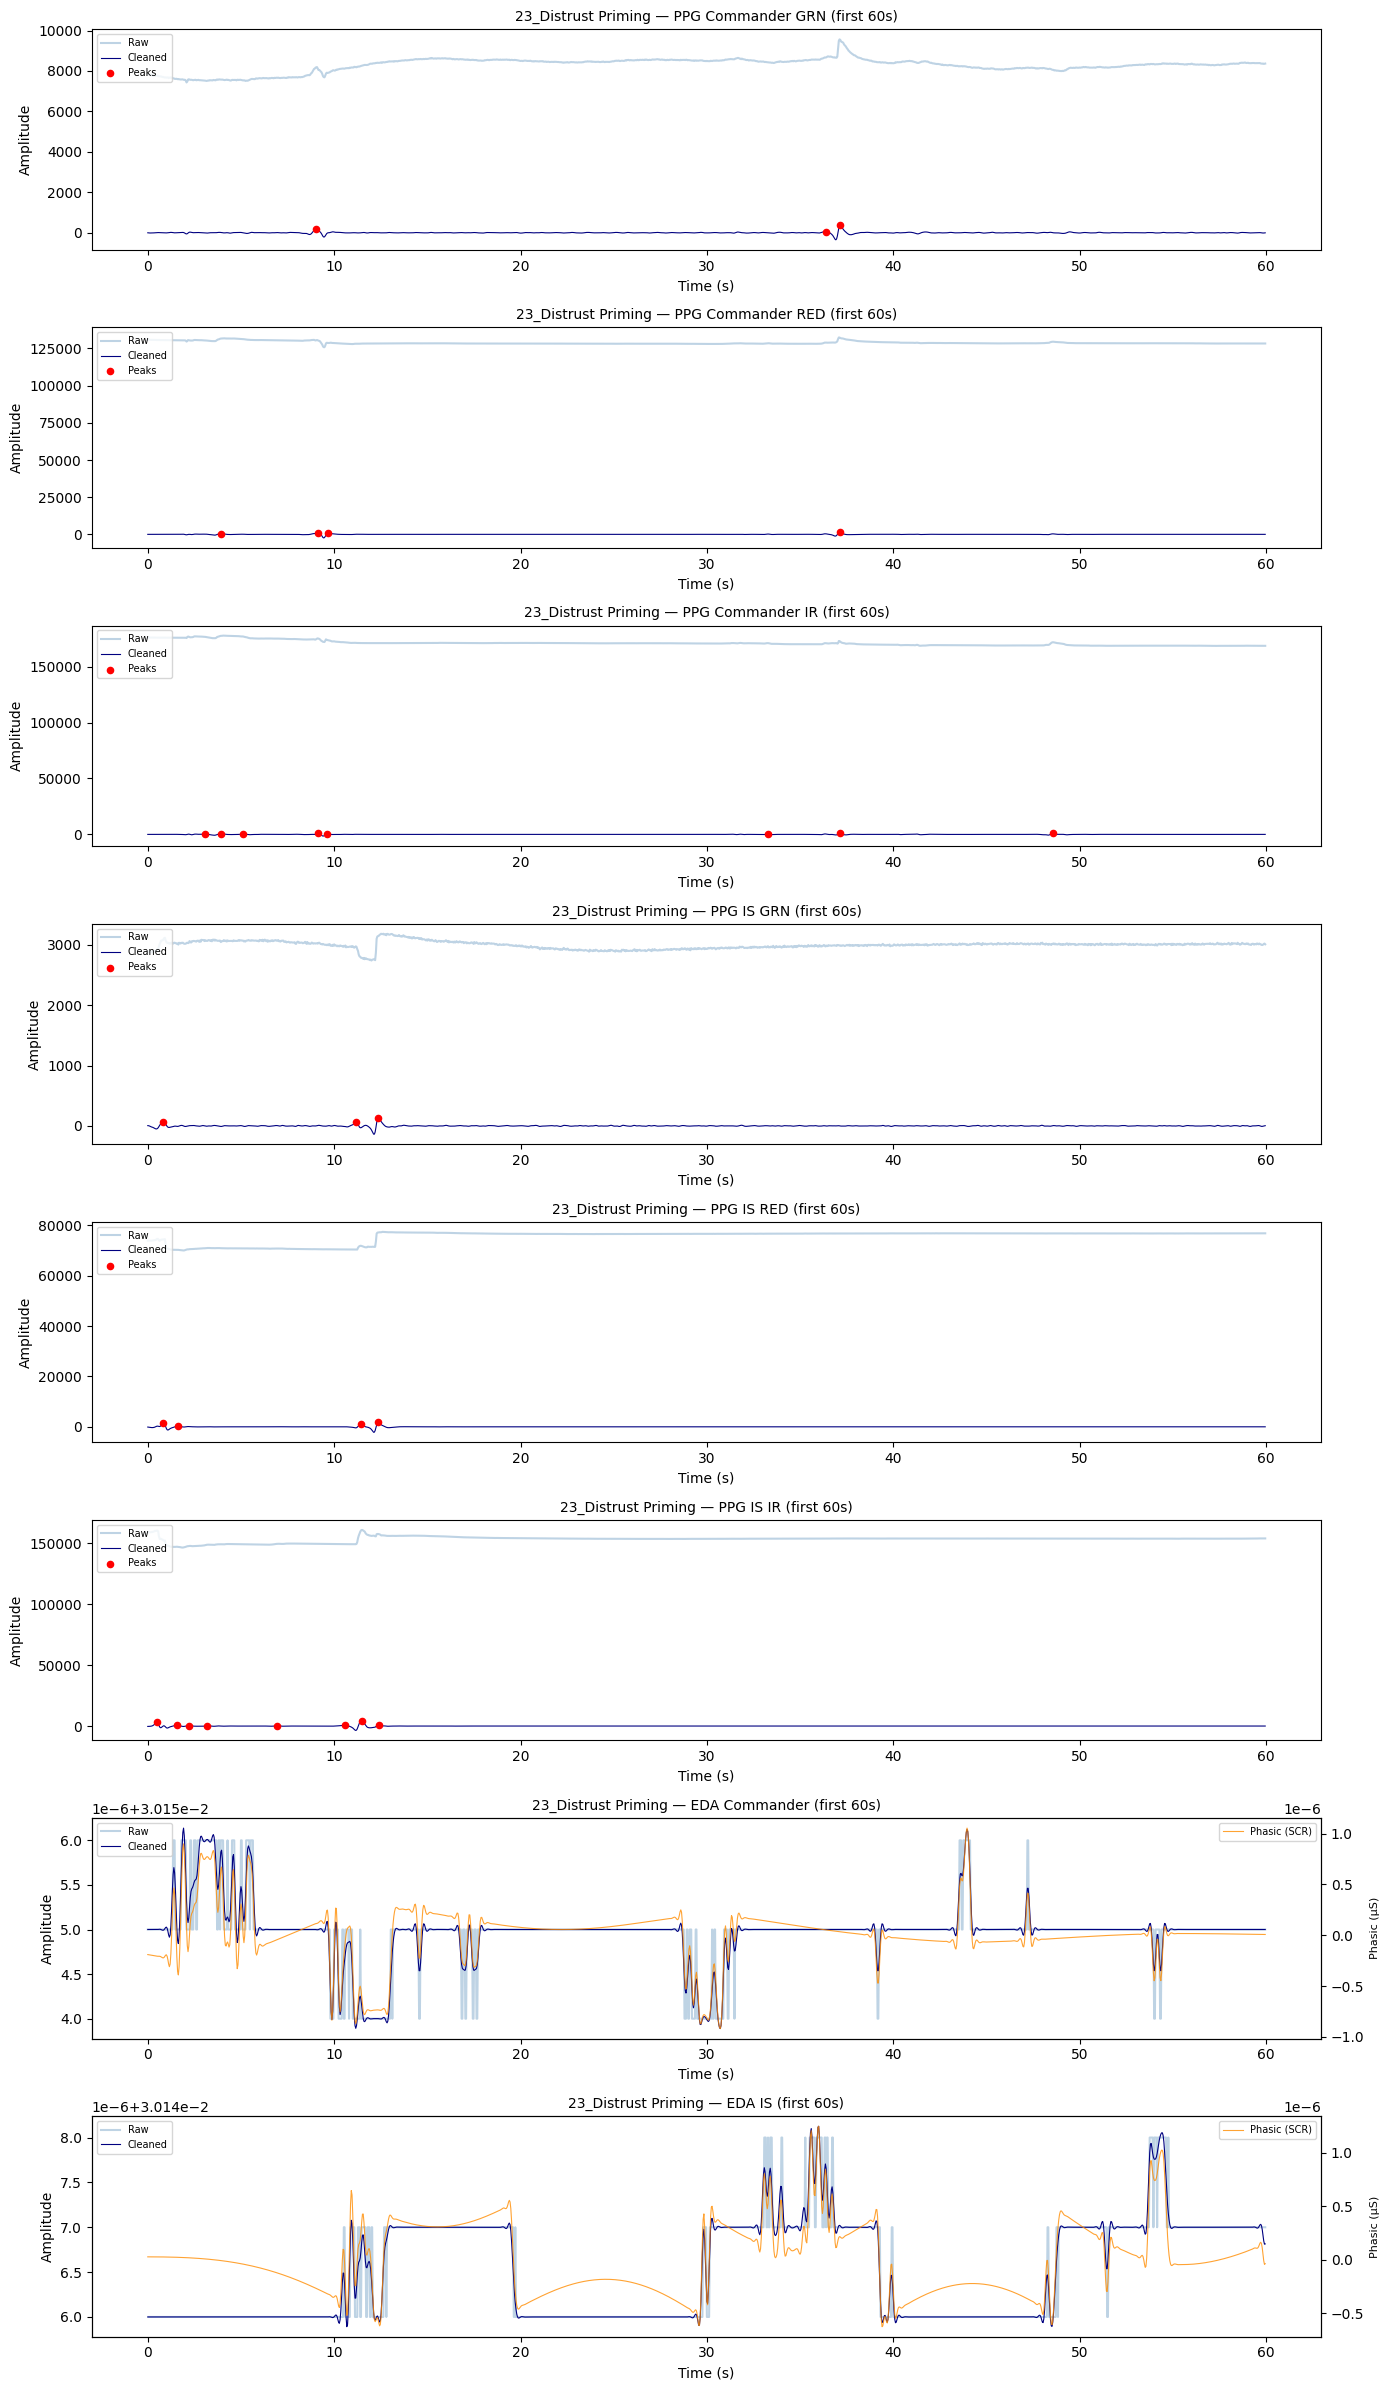

In [268]:
PPG_STREAMS = [
    ("ppg_GRN_C", "PPG_GRN_C", "PPG Commander GRN"),
    ("ppg_RED_C", "PPG_RED_C", "PPG Commander RED"),
    ("ppg_IR_C",  "PPG_IR_C",  "PPG Commander IR"),
    ("ppg_GRN_IS","PPG_GRN_IS","PPG IS GRN"),
    ("ppg_RED_IS","PPG_RED_IS","PPG IS RED"),
    ("ppg_IR_IS", "PPG_IR_IS", "PPG IS IR"),
]
EDA_STREAMS = [("eda_C", "EDA_C", "EDA Commander"), ("eda_IS", "EDA_IS", "EDA IS")]


def plot_group(group_label, group_df, results, sampling_rate=25, n_seconds=60):
    """Diagnostic plot: raw vs. cleaned signal for all PPG variants and EDA."""
    plot_items = [
        (key, raw_col, "PPG_Clean", title)
        for key, raw_col, title in PPG_STREAMS
        if key in results and results[key]["signals"] is not None
    ] + [
        (key, raw_col, "EDA_Clean", title)
        for key, raw_col, title in EDA_STREAMS
        if key in results and results[key]["signals"] is not None
    ]
    if not plot_items:
        print(f"[{group_label}] Nothing to plot.")
        return

    n_preview = n_seconds * sampling_rate
    fig, axes = plt.subplots(len(plot_items), 1, figsize=(14, 3 * len(plot_items)), sharex=False)
    if len(plot_items) == 1:
        axes = [axes]

    for ax, (key, raw_col, clean_col, title) in zip(axes, plot_items):
        signals = results[key]["signals"]
        if raw_col in group_df.columns:
            raw = group_df[raw_col].values[:n_preview]
            ax.plot(np.arange(len(raw)) / sampling_rate, raw, alpha=0.35, color="steelblue", label="Raw")

        cleaned = signals[clean_col].values[:n_preview]
        t_clean = np.arange(len(cleaned)) / sampling_rate
        ax.plot(t_clean, cleaned, color="navy", linewidth=0.8, label="Cleaned")

        if "PPG_Peaks" in signals.columns:
            peak_mask = signals["PPG_Peaks"].values[:n_preview].astype(bool)
            ax.scatter(t_clean[peak_mask], cleaned[peak_mask], color="red", s=20, zorder=5, label="Peaks")

        if "EDA_Phasic" in signals.columns:
            phasic = signals["EDA_Phasic"].values[:n_preview]
            ax2 = ax.twinx()
            ax2.plot(t_clean, phasic, color="darkorange", linewidth=0.8, alpha=0.8, label="Phasic (SCR)")
            ax2.set_ylabel("Phasic (µS)", fontsize=8)
            ax2.legend(loc="upper right", fontsize=7)

        ax.set_title(f"{group_label} — {title} (first {n_seconds}s)", fontsize=10)
        ax.set_xlabel("Time (s)"); ax.set_ylabel("Amplitude")
        ax.legend(loc="upper left", fontsize=7)

    plt.tight_layout(); plt.show()


def _recover_group_df(label):
    """Recover the rows for one group label using the project's label scheme."""
    active_cols = [c for c in GROUP_COLS if c in df.columns]
    if not active_cols:
        return df
    mask = pd.Series([True] * len(df))
    for col, val in zip(active_cols, label.split("_")):
        mask &= df[col].astype(str) == val
    return df[mask].reset_index(drop=True)


for label, results in all_results.items():
    plot_group(label, _recover_group_df(label), results, SAMPLING_RATE, n_seconds=60)

In [269]:
def summarize_hrv(all_results):
    """Collect HRV summary rows from all groups/streams into one DataFrame."""
    rows = []
    for group_label, results in all_results.items():
        for key, _, title in PPG_STREAMS:
            if key in results and results[key]["hrv"] is not None:
                hrv_row = results[key]["hrv"].copy()
                hrv_row.insert(0, "Stream", title)
                hrv_row.insert(0, "Group", group_label)
                rows.append(hrv_row)
    if not rows:
        print("No HRV data available.")
        return None
    return pd.concat(rows, ignore_index=True)


hrv_summary = summarize_hrv(all_results)
if hrv_summary is not None:
    display(hrv_summary)

,Group,Stream,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,...,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC,HRV_Symbolic_EqualProb4_0V,HRV_Symbolic_EqualProb4_1V,HRV_Symbolic_EqualProb4_2LV,HRV_Symbolic_EqualProb4_2UV
0,23_Distrust Priming,PPG Commander GRN,5503.116371,19511.175326,11552.123491,14383.574975,10667.549280,16493.799083,60042.045356,18326.871463,...,0.238659,0.188142,0.125159,1.881598,1.866426,0.478536,0.144554,0.386139,0.097030,0.372277
1,23_Distrust Priming,PPG Commander RED,5091.438980,28180.449303,10905.909108,15392.805423,10337.934914,18859.576126,4325.714841,21831.126413,...,0.227789,0.185655,0.076844,1.949632,1.394809,0.563611,0.133455,0.367459,0.095064,0.404022
2,23_Distrust Priming,PPG Commander IR,3732.122830,11207.717758,30084.515200,8484.600884,18028.987697,13140.348791,26916.989693,17738.632354,...,0.447631,0.351163,0.205703,1.939027,1.766749,0.586443,0.125837,0.361446,0.111111,0.401606
3,23_Distrust Priming,PPG IS GRN,10324.428044,40964.666016,59815.548554,24581.848596,35017.322512,34299.909776,46452.494608,32345.655208,...,0.253098,0.198395,0.133211,1.864037,1.601603,0.566645,0.137546,0.423792,0.107807,0.330855
4,23_Distrust Priming,PPG IS RED,9851.971831,51730.376040,29087.087101,28845.814113,27748.181308,38474.054008,34916.712912,59968.747572,...,0.167026,0.128985,0.074199,1.939119,1.535355,0.487837,0.092199,0.368794,0.113475,0.425532
5,23_Distrust Priming,PPG IS IR,6909.432099,26160.322365,18744.491251,22616.890404,21943.913582,26845.219760,19409.156663,27691.943635,...,0.311015,0.242937,0.119490,1.903503,1.720521,0.491903,0.106700,0.411911,0.111663,0.369727


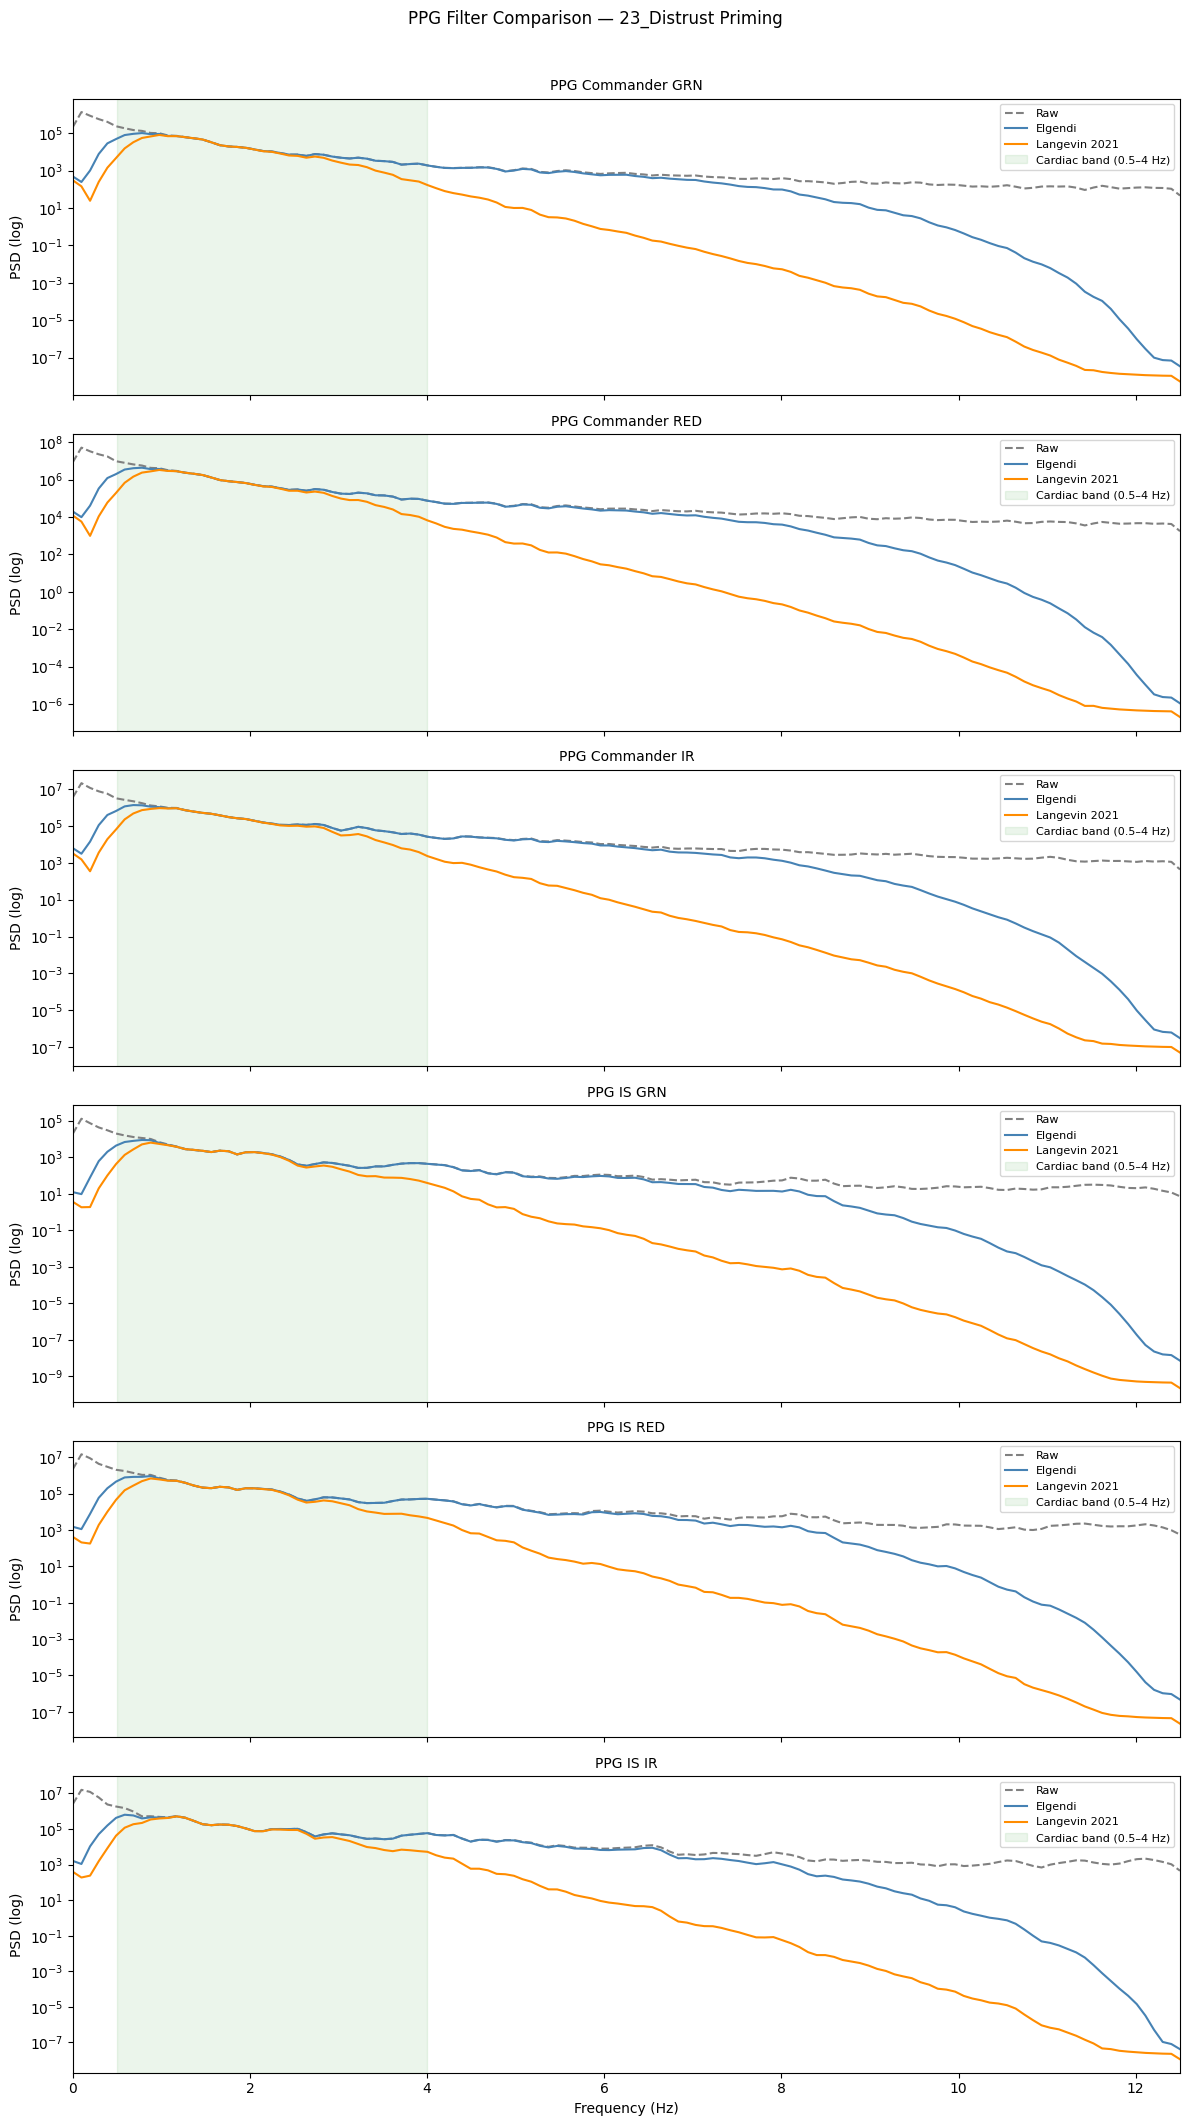

In [270]:
def plot_ppg_filter_comparison(group_df, group_label, sampling_rate=25):
    """Plot power spectral density of raw vs. elgendi vs. langevin2021 for each PPG stream.
    Shaded region marks the cardiac band (0.5–4 Hz)."""
    present = [(key, raw_col, title) for key, raw_col, title in PPG_STREAMS
               if raw_col in group_df.columns and group_df[raw_col].notna().any()]
    if not present:
        print(f"[{group_label}] No PPG columns found.")
        return

    fig, axes = plt.subplots(len(present), 1, figsize=(12, 3.5 * len(present)), sharex=True)
    if len(present) == 1:
        axes = [axes]
    fig.suptitle(f"PPG Filter Comparison — {group_label}", fontsize=12, y=1.01)

    for ax, (key, raw_col, title) in zip(axes, present):
        raw = group_df[raw_col].dropna().values.astype(float)
        elgendi  = nk.ppg_clean(raw, sampling_rate=sampling_rate, method="elgendi")
        langevin = nk.ppg_clean(raw, sampling_rate=sampling_rate, method="langevin2021")
        for signal, lab, color, ls in [(raw, "Raw", "gray", "--"),
                                        (elgendi, "Elgendi", "steelblue", "-"),
                                        (langevin, "Langevin 2021", "darkorange", "-")]:
            freqs, psd = welch(signal, fs=sampling_rate, nperseg=min(256, len(signal)))
            ax.semilogy(freqs, psd, linestyle=ls, color=color, linewidth=1.5, label=lab)
        ax.axvspan(0.5, 4.0, alpha=0.08, color="green", label="Cardiac band (0.5–4 Hz)")
        ax.set_xlim(0, sampling_rate / 2); ax.set_ylabel("PSD (log)")
        ax.set_title(title, fontsize=10); ax.legend(fontsize=8, loc="upper right")

    axes[-1].set_xlabel("Frequency (Hz)")
    plt.tight_layout(); plt.show()


first_label = list(all_results.keys())[0]
plot_ppg_filter_comparison(_recover_group_df(first_label), first_label, SAMPLING_RATE)

# Artifact Handling: MAD masking vs. Kubios correction

Compares two ways of handling motion artifacts before computing HRV:

- **Kubios correction** (`nk.signal_fixpeaks`, method="kubios"; Lipponen & Tarvainen 2019) — a *validated, post-detection* method that repairs implausible inter-beat intervals.
- **MAD masking** (custom; a Hampel-style outlier mask) — a *pre-detection* step that removes large-amplitude artifact regions (>k·MAD from the median) so the adaptive peak-detection threshold isn't poisoned, then detects on the clean runs.

Detection is always run **per task segment** (HH / LL / M) to avoid one local artifact poisoning the global threshold. Quality = **physiological fraction**: % of inter-beat intervals in 40–180 bpm (333–1500 ms).

In [271]:
# --- MAD vs Kubios configuration ---
VALIDATE_PPG_COL = "PPG_GRN_C"      # PPG stream for the single-participant comparison
SEG_COL          = "Reliability"    # column holding HH / LL / M block labels
TASK_SEGMENTS    = ["HH", "LL", "M"]
MIN_RUN_S        = 20               # ignore clean runs shorter than this
MAD_K            = 8                # artifact threshold in robust-SDs (MAD) from the median
MAD_PAD_S        = 2.0              # seconds padded around each artifact region


def _get_group_df(label):
    """Recover the rows for one group label (same as _recover_group_df; kept for this section)."""
    return _recover_group_df(label)


def _clean_and_findpeaks(raw_valid, sampling_rate, clean_method, peak_method="elgendi"):
    """Clean, then detect peaks. Returns empty peaks on failure (flat/dead segments)."""
    try:
        cleaned = nk.ppg_clean(raw_valid, sampling_rate=sampling_rate, method=clean_method)
        info = nk.ppg_findpeaks(cleaned, sampling_rate=sampling_rate, method=peak_method)
        return cleaned, np.asarray(info["PPG_Peaks"], dtype=int)
    except (IndexError, ValueError):
        cleaned = np.zeros(len(raw_valid)) if len(raw_valid) else np.array([])
        return cleaned, np.array([], dtype=int)


def artifact_mask(clean, sampling_rate, k=MAD_K, pad_s=MAD_PAD_S, min_floor=None):
    """Boolean mask of artifact regions: samples > k robust-SDs (MAD) from the median,
    grouped into contiguous events, each padded by pad_s seconds (Hampel-style)."""
    med = np.median(clean)
    mad = np.median(np.abs(clean - med)) * 1.4826
    if mad == 0:
        return np.zeros(len(clean), bool)
    thresh = k * mad
    if min_floor is not None:
        thresh = max(thresh, min_floor)
    flag = np.abs(clean - med) > thresh
    lab, n = cc_label(flag)
    pad = int(pad_s * sampling_rate)
    mask = np.zeros(len(clean), bool)
    for i in range(1, n + 1):
        idx = np.where(lab == i)[0]
        mask[max(0, idx[0] - pad): min(len(clean), idx[-1] + pad + 1)] = True
    return mask


def detect_segment(raw_segment, sampling_rate, method="langevin2021", min_run_s=MIN_RUN_S):
    """MAD-mask artifacts, re-detect on each clean run >= min_run_s, pool the beats.
    Returns dict with peak count, pooled IBIs, physiological fraction, masked seconds."""
    clean = nk.ppg_clean(raw_segment, sampling_rate=sampling_rate, method=method)
    mask = artifact_mask(clean, sampling_rate)
    raw_masked = np.asarray(raw_segment, float).copy()
    raw_masked[mask] = np.nan
    idx = np.where(~np.isnan(raw_masked))[0]
    if len(idx) == 0:
        return dict(n_peaks=0, ibi=np.array([]), pct_phys=0.0, masked_s=mask.sum() / sampling_rate)

    splits = np.where(np.diff(idx) > 1)[0]
    starts = np.r_[idx[0], idx[splits + 1]]
    ends   = np.r_[idx[splits], idx[-1]]

    all_ibi, n_peaks = [], 0
    for s, e in zip(starts, ends):
        if (e - s) < min_run_s * sampling_rate:
            continue
        _, pk = _clean_and_findpeaks(raw_segment[s:e + 1], sampling_rate, method)
        n_peaks += len(pk)
        all_ibi.append(np.diff(pk) / sampling_rate * 1000)

    ibi = np.concatenate(all_ibi) if all_ibi else np.array([])
    ok = (ibi >= 333) & (ibi <= 1500)
    return dict(n_peaks=n_peaks, ibi=ibi,
                pct_phys=100 * ok.mean() if len(ibi) else 0.0,
                masked_s=mask.sum() / sampling_rate)


def kubios_correct(peaks, sr):
    """Validated peak correction (Lipponen & Tarvainen 2019). Returns corrected indices."""
    try:
        out = nk.signal_fixpeaks(np.asarray(peaks, int), sampling_rate=sr, method="kubios")
    except Exception:
        out = nk.signal_fixpeaks(np.asarray(peaks, int), sampling_rate=sr, method="neurokit")
    corr = out[1] if isinstance(out, (tuple, list)) else out
    return np.asarray(corr, int)


def _phys(ibi):
    """% of IBIs in 40-180 bpm (333-1500 ms)."""
    ok = (ibi >= 333) & (ibi <= 1500)
    return 100 * ok.mean() if len(ibi) else 0.0


def _stats(peaks, sr):
    """Peak count, physiological fraction, RMSSD, HR from a peak series."""
    peaks = np.asarray(peaks, int)
    if len(peaks) < 3:
        return dict(n=len(peaks), pct_phys=0.0, rmssd=np.nan, hr=np.nan)
    ibi = np.diff(peaks) / sr * 1000
    ok = (ibi >= 333) & (ibi <= 1500)
    rmssd = np.sqrt(np.mean(np.diff(ibi[ok]) ** 2)) if ok.sum() > 2 else np.nan
    hr = 60000 / np.mean(ibi[ok]) if ok.sum() else np.nan
    return dict(n=len(peaks), pct_phys=100 * ok.mean(), rmssd=rmssd, hr=hr)

## Single-participant comparison (per segment)

Three stages side by side: (1) detect only, (2) + Kubios, (3) MAD mask with data cost.

In [272]:
PARTICIPANT = "23_Distrust Priming"

print(f"{'seg':>4} | {'stage':<22} | {'peaks':>6} {'%phys':>6} {'RMSSD':>8} {'HR':>5} | "
      f"{'kept_s':>7} {'masked_s':>8} {'%masked':>7}")
print("-" * 92)

for seg in TASK_SEGMENTS:
    g = _get_group_df(PARTICIPANT)
    raw = g[g[SEG_COL].astype(str) == seg][VALIDATE_PPG_COL].dropna().values.astype(float)
    if len(raw) < MIN_RUN_S * SAMPLING_RATE:
        print(f"{seg:>4} | too short"); continue
    total_s = len(raw) / SAMPLING_RATE

    _, peaks_raw = _clean_and_findpeaks(raw, SAMPLING_RATE, "langevin2021")
    s_raw = _stats(peaks_raw, SAMPLING_RATE)
    s_kub = _stats(kubios_correct(peaks_raw, SAMPLING_RATE), SAMPLING_RATE)

    r = detect_segment(raw, SAMPLING_RATE, method="langevin2021")
    ibi = r["ibi"]; ok = (ibi >= 333) & (ibi <= 1500)
    s_mad = dict(n=r["n_peaks"], pct_phys=r["pct_phys"],
                 rmssd=np.sqrt(np.mean(np.diff(ibi[ok]) ** 2)) if ok.sum() > 2 else np.nan,
                 hr=60000 / np.mean(ibi[ok]) if ok.sum() else np.nan)
    masked_s = r["masked_s"]; kept_s = total_s - masked_s; pct_masked = 100 * masked_s / total_s

    for name, s, kept, msk, pct in [
        ("1. detect only",          s_raw, total_s, 0.0,      0.0),
        ("2. + Kubios (validated)", s_kub, total_s, 0.0,      0.0),
        ("3. MAD mask (custom)",    s_mad, kept_s,  masked_s, pct_masked),
    ]:
        print(f"{seg:>4} | {name:<22} | {s['n']:>6} {s['pct_phys']:>6.0f} "
              f"{s['rmssd'] if not np.isnan(s['rmssd']) else 0:>8.1f} "
              f"{s['hr'] if not np.isnan(s['hr']) else 0:>5.0f} | "
              f"{kept:>7.0f} {msk:>8.0f} {pct:>6.0f}%")
    print(f"{seg:>4} | (segment total: {total_s:.0f}s)")
    print("-" * 92)

 seg | stage                  |  peaks  %phys    RMSSD    HR |  kept_s masked_s %masked
--------------------------------------------------------------------------------------------
  HH | 1. detect only         |    838    100    138.0    82 |     616        0      0%
  HH | 2. + Kubios (validated) |    858    100     68.4    84 |     616        0      0%
  HH | 3. MAD mask (custom)   |    831    100    135.6    82 |     612        4      1%
  HH | (segment total: 616s)
--------------------------------------------------------------------------------------------
  LL | 1. detect only         |    673     90    341.4    76 |     615        0      0%
  LL | 2. + Kubios (validated) |    684     91    345.1    75 |     615        0      0%
  LL | 3. MAD mask (custom)   |    467     95    305.6    78 |     504      111     18%
  LL | (segment total: 615s)
--------------------------------------------------------------------------------------------
   M | 1. detect only         |     38     57

## Full-dataset scan (per ID)

Three-stage comparison across every ID/channel in the full dataset, pooled to ID level. Saves a per-ID quality table.

In [273]:
FULL_PATH = "aoi_physio_survey.csv"
CHANNELS  = ["PPG_GRN_C", "PPG_GRN_IS"]
ID_COL    = "ID"
GROUP_BY  = [ID_COL]                # -> ["ID","Condition"] to split by priming too

if "df_full" not in globals():
    print(f"Loading {FULL_PATH} ...")
    df_full = pd.read_csv(FULL_PATH)
print(f"df_full: {df_full.shape[0]:,} rows x {df_full.shape[1]} cols")

seg_col = None
for c in df_full.columns:
    if {"HH", "LL", "M"} & set(df_full[c].dropna().astype(str).unique()):
        seg_col = c; break
print(f"segment column: {seg_col!r}\n")


def scan_id_channel(sub, ch, sr=SAMPLING_RATE):
    """Per-segment three-stage comparison for one ID/channel, pooled to ID level."""
    if ch not in sub.columns or not sub[ch].notna().any():
        return None
    total_s = sub[ch].notna().sum() / sr
    if seg_col and seg_col in sub.columns:
        units = [sub[sub[seg_col].astype(str) == s][ch].dropna().values.astype(float)
                 for s in TASK_SEGMENTS if (sub[seg_col].astype(str) == s).any()]
    else:
        units = [sub[ch].dropna().values.astype(float)]

    ibi_raw, ibi_kub, ibi_mad = [], [], []
    n_raw = n_kub = n_mad = 0; masked_s = 0.0; kub_failed = False
    for raw in units:
        if len(raw) < MIN_RUN_S * sr:
            continue
        _, pk = _clean_and_findpeaks(raw, sr, "langevin2021")
        ibi_raw.append(np.diff(pk) / sr * 1000); n_raw += len(pk)
        try:
            pkk = kubios_correct(pk, sr)
        except Exception:
            pkk = pk; kub_failed = True
        ibi_kub.append(np.diff(pkk) / sr * 1000); n_kub += len(pkk)
        r = detect_segment(raw, sr, method="langevin2021")
        ibi_mad.append(r["ibi"]); n_mad += r["n_peaks"]; masked_s += r["masked_s"]

    cat = lambda L: np.concatenate(L) if L else np.array([])
    ibi_raw, ibi_kub, ibi_mad = cat(ibi_raw), cat(ibi_kub), cat(ibi_mad)
    ok = (ibi_mad >= 333) & (ibi_mad <= 1500)
    hr = 60000 / np.mean(ibi_mad[ok]) if ok.sum() else np.nan
    return dict(total_s=total_s, masked_s=masked_s,
                pct_masked=100 * masked_s / total_s if total_s else np.nan,
                n_raw=n_raw, phys_raw=_phys(ibi_raw),
                n_kub=n_kub, phys_kub=_phys(ibi_kub),
                n_mad=n_mad, phys_mad=_phys(ibi_mad),
                hr_mad=hr, kub_failed=kub_failed)


rows = []
groups = df_full.groupby(GROUP_BY, sort=False)
print(f"Scanning {len(groups)} groups x {len(CHANNELS)} channels ...\n")
print(f"{'ID/channel':>20} | {'detect':>12} | {'+Kubios':>12} | {'MAD':>12} | {'masked':>12}")
print("-" * 82)
for gkey, sub in groups:
    gid = gkey if not isinstance(gkey, tuple) else "_".join(map(str, gkey))
    for ch in CHANNELS:
        res = scan_id_channel(sub, ch)
        if res is None:
            rows.append(dict(ID=gid, channel=ch, note="missing/all-NaN")); continue
        rows.append(dict(ID=gid, channel=ch, **res))
        kf = "!" if res["kub_failed"] else " "
        print(f"{str(gid)[:11] + '/' + ch.replace('PPG_GRN_', ''):>20} | "
              f"{res['n_raw']:4d}pk {res['phys_raw']:3.0f}% | "
              f"{res['n_kub']:4d}pk {res['phys_kub']:3.0f}%{kf}| "
              f"{res['n_mad']:4d}pk {res['phys_mad']:3.0f}% | "
              f"{res['masked_s']:4.0f}s {res['pct_masked']:2.0f}%")

qc = pd.DataFrame(rows)
qc.to_csv("mad_kubios_scan_by_id.csv", index=False)
print(f"\nSaved -> mad_kubios_scan_by_id.csv  ({len(qc)} rows)")

df_full: 4,058,617 rows x 80 cols
segment column: 'Reliability'

Scanning 52 groups x 2 channels ...

          ID/channel |       detect |      +Kubios |          MAD |       masked
----------------------------------------------------------------------------------
                 4/C |  514pk  62% |  536pk  56% | 1512pk  96% |  317s 11%
                4/IS | 1436pk  92% | 1480pk  92% | 1849pk  98% |  229s  8%
                 6/C | 2793pk  99% | 3050pk 100% | 2788pk  99% |    4s  0%
                6/IS | 1485pk  90% | 1536pk  92% | 1911pk  96% |   23s  1%
                 7/C | 2969pk  98% | 3066pk 100% | 2977pk  98% |   15s  0%
                7/IS | 1751pk  84% | 1808pk  86% | 2085pk  96% |  219s  3%
                10/C | 1956pk  84% | 2059pk  86% | 1763pk  93% |  380s 11%
               10/IS | 1607pk  78% | 1691pk  74% |  957pk  84% |  848s 25%
                12/C | 3266pk  99% | 3537pk 100% | 3266pk  99% |    9s  0%
               12/IS | 2726pk  95% | 2911pk 100% | 2726pk  

In [274]:
if "phys_mad" in qc.columns:
    v = qc.dropna(subset=["phys_mad"]).copy()
    print(f"Mean physiological fraction:  detect {v['phys_raw'].mean():.0f}%  "
          f"+Kubios {v['phys_kub'].mean():.0f}%  MAD {v['phys_mad'].mean():.0f}%")
    print(f"MAD masking: median {v['pct_masked'].median():.1f}%  "
          f"mean {v['pct_masked'].mean():.1f}%  max {v['pct_masked'].max():.1f}%")

    close = v[v['phys_kub'] >= v['phys_mad'] - 3]
    print(f"\nIDs where Kubios alone ~matches MAD (within 3%): {len(close)} of {len(v)}")

    v["mad_gain"] = v["phys_mad"] - v["phys_kub"]
    print("\nLargest MAD advantage over Kubios (top 10):")
    print(v.sort_values("mad_gain", ascending=False)
          [["ID", "channel", "phys_raw", "phys_kub", "phys_mad", "pct_masked", "mad_gain"]]
          .head(10).round(1).to_string(index=False))

    dead = v[v["n_mad"] == 0]
    if len(dead):
        print("\nStreams with zero detectable beats (dead/flat -- inspect sensor):")
        print(dead[["ID", "channel", "total_s"]].round(0).to_string(index=False))

Mean physiological fraction:  detect 88%  +Kubios 88%  MAD 96%
MAD masking: median 1.8%  mean 5.4%  max 37.3%

IDs where Kubios alone ~matches MAD (within 3%): 54 of 104

Largest MAD advantage over Kubios (top 10):
ID    channel  phys_raw  phys_kub  phys_mad  pct_masked  mad_gain
30 PPG_GRN_IS      40.2      38.3      97.0         2.7      58.6
28 PPG_GRN_IS      49.2      47.1      99.4         6.5      52.3
18 PPG_GRN_IS      50.4      47.5      92.2        11.1      44.7
 4  PPG_GRN_C      62.4      55.5      96.3        11.2      40.7
48 PPG_GRN_IS      60.1      56.2      93.5        12.8      37.3
32 PPG_GRN_IS      59.3      53.7      90.6        20.5      37.0
34 PPG_GRN_IS      69.1      58.2      92.5        16.3      34.4
60  PPG_GRN_C      69.5      66.4      97.7        14.4      31.3
54  PPG_GRN_C      69.2      62.9      92.9         6.7      30.0
14  PPG_GRN_C      70.8      66.1      95.7        12.1      29.6


23_Distrust Priming: 2800s of (post-NaN-mask) signal


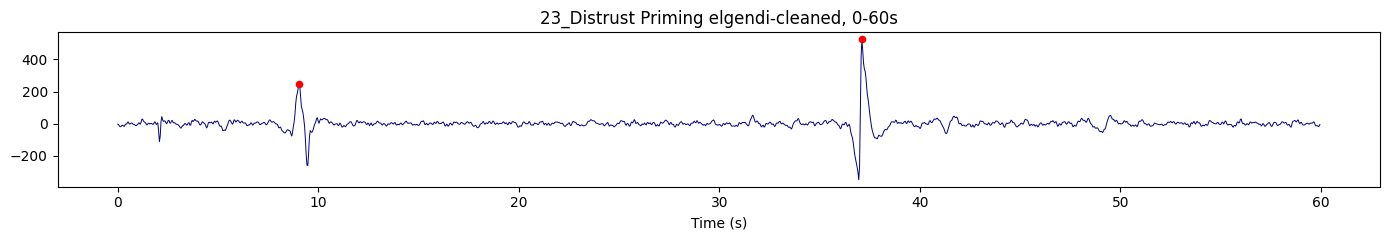

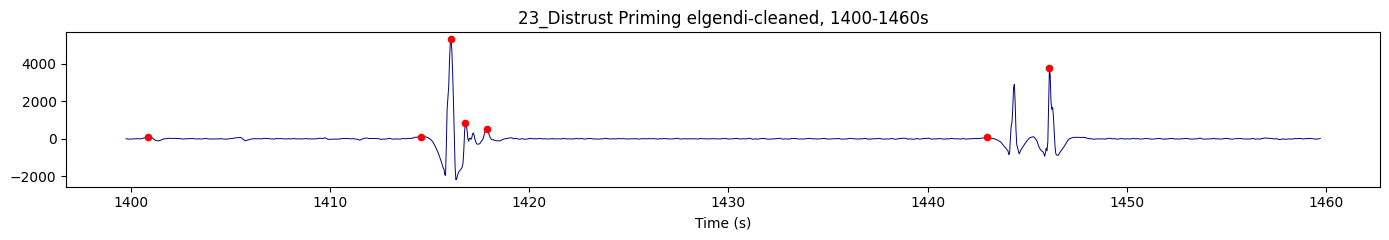

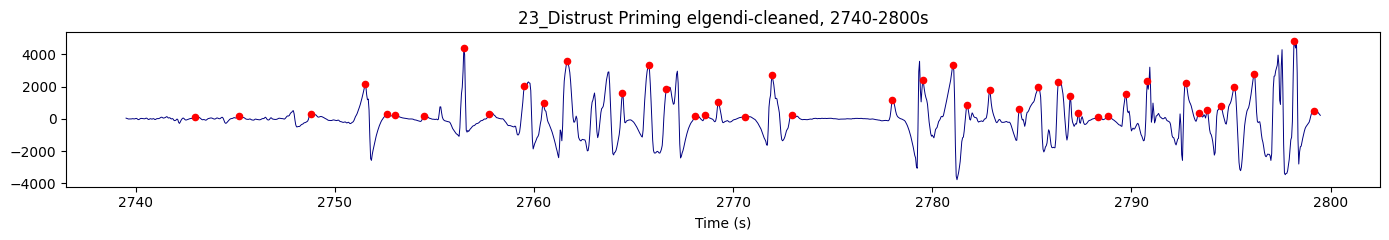

elgendi: 53% of IBIs in 40-180 bpm range (212 usable intervals)
langevin: 70% of IBIs in 40-180 bpm range (354 usable intervals)


In [275]:
# --- Deep-dive on one problem participant ---
PARTICIPANT = "23_Distrust Priming"
res = validation[PARTICIPANT]

# 1) Look at the signal across several windows, not just the first 60 s
import numpy as np
clean = res["_clean_e"]
total_s = len(clean) / SAMPLING_RATE
print(f"{PARTICIPANT}: {total_s:.0f}s of (post-NaN-mask) signal")

# Plot 3 windows: start, middle, end — to see where detection works vs fails
for start_s in [0, total_s/2, max(0, total_s-60)]:
    a = int(start_s * SAMPLING_RATE)
    b = min(len(clean), a + 60 * SAMPLING_RATE)
    t = np.arange(a, b) / SAMPLING_RATE
    import matplotlib.pyplot as plt
    plt.figure(figsize=(14, 2.5))
    plt.plot(t, clean[a:b], color="navy", lw=0.7)
    pk = res["_peaks_e"]; pk = pk[(pk >= a) & (pk < b)]
    plt.scatter(pk / SAMPLING_RATE, clean[pk], color="red", s=20, zorder=5)
    plt.title(f"{PARTICIPANT} elgendi-cleaned, {start_s:.0f}-{start_s+60:.0f}s")
    plt.xlabel("Time (s)"); plt.tight_layout(); plt.show()

# 2) What fraction of detected IBIs are even physiologically plausible (40-180 bpm)?
def physio_fraction(peaks, sr, lo_ms=333, hi_ms=1500):
    ibi = np.diff(np.asarray(peaks, int)) / sr * 1000.0
    if len(ibi) == 0:
        return np.nan, 0
    ok = (ibi >= lo_ms) & (ibi <= hi_ms)
    return 100.0 * ok.mean(), int(ok.sum())

for name, key in [("elgendi", "_peaks_e"), ("langevin", "_peaks_l")]:
    pct, n = physio_fraction(res[key], SAMPLING_RATE)
    print(f"{name}: {pct:.0f}% of IBIs in 40-180 bpm range ({n} usable intervals)")

In [276]:
EXCLUDE_FIRST_S = 60   # drop the setup/artifact period at the start
PARTICIPANT     = "23_Distrust Priming"

import numpy as np
group_df = _get_group_df(PARTICIPANT)
raw = group_df[VALIDATE_PPG_COL].values.astype(float)
raw_v = raw[~np.isnan(raw)]
raw_trim = raw_v[int(EXCLUDE_FIRST_S * SAMPLING_RATE):]

print(f"{PARTICIPANT}: {len(raw_v)/SAMPLING_RATE:.0f}s total, "
      f"analysing {len(raw_trim)/SAMPLING_RATE:.0f}s after dropping first {EXCLUDE_FIRST_S}s\n")

for method in ["elgendi", "langevin2021"]:
    cleaned, peaks = _clean_and_findpeaks(raw_trim, SAMPLING_RATE, method)
    ibi = np.diff(peaks) / SAMPLING_RATE * 1000
    ok = (ibi >= 333) & (ibi <= 1500)   # 40-180 bpm
    if ok.sum():
        print(f"{method:13s}: {len(peaks)} peaks, {100*ok.mean():.0f}% physiological, "
              f"mean IBI {np.mean(ibi[ok]):.0f} ms ({60000/np.mean(ibi[ok]):.0f} bpm)")
    else:
        print(f"{method:13s}: {len(peaks)} peaks, 0% physiological")

23_Distrust Priming: 2800s total, analysing 2740s after dropping first 60s

elgendi      : 395 peaks, 54% physiological, mean IBI 979 ms (61 bpm)
langevin2021 : 502 peaks, 70% physiological, mean IBI 914 ms (66 bpm)


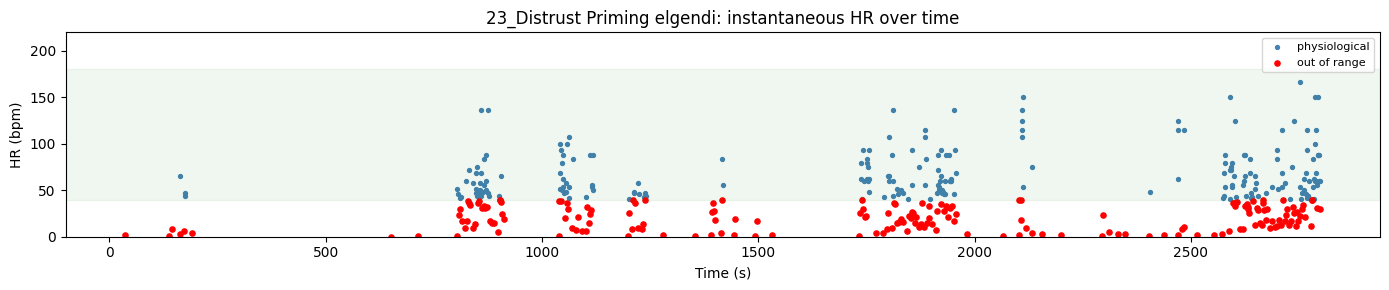

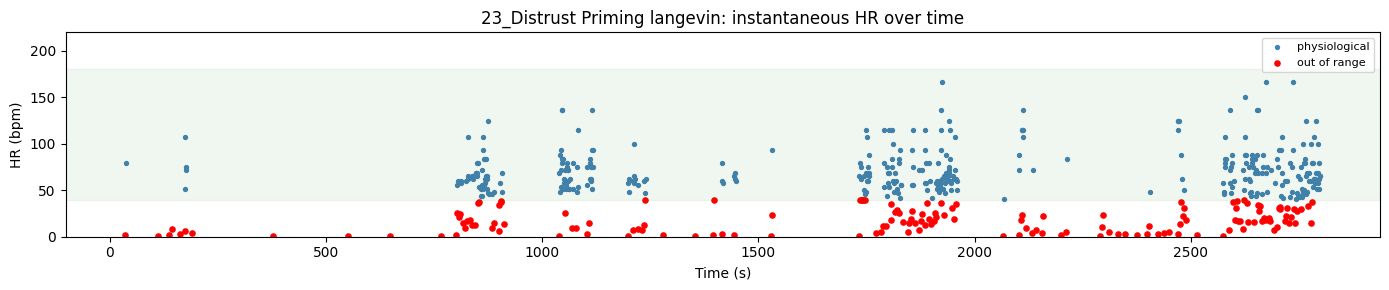

In [277]:
PARTICIPANT = "23_Distrust Priming"
res = validation[PARTICIPANT]
import numpy as np, matplotlib.pyplot as plt

for name, key in [("elgendi", "_peaks_e"), ("langevin", "_peaks_l")]:
    peaks = np.asarray(res[key], int)
    if len(peaks) < 3:
        continue
    ibi = np.diff(peaks) / SAMPLING_RATE * 1000
    t = peaks[1:] / SAMPLING_RATE
    ok = (ibi >= 333) & (ibi <= 1500)   # 40-180 bpm
    plt.figure(figsize=(14, 3))
    plt.scatter(t[ok], 60000 / ibi[ok], s=8, color="steelblue", label="physiological")
    plt.scatter(t[~ok], np.clip(60000 / ibi[~ok], 0, 300), s=14, color="red", label="out of range")
    plt.axhspan(40, 180, alpha=0.06, color="green")
    plt.ylim(0, 220)
    plt.title(f"{PARTICIPANT} {name}: instantaneous HR over time")
    plt.xlabel("Time (s)"); plt.ylabel("HR (bpm)")
    plt.legend(fontsize=8, loc="upper right"); plt.tight_layout(); plt.show()

In [278]:
SEG_COL       = "Reliability"
TASK_SEGMENTS = ["HH", "LL", "M"]

g = _get_group_df(PARTICIPANT)
for seg in TASK_SEGMENTS:
    sub = g[g[SEG_COL].astype(str) == seg] if SEG_COL in g.columns else g.iloc[0:0]
    raw_seg = sub[VALIDATE_PPG_COL].dropna().values.astype(float)
    if len(raw_seg) < SAMPLING_RATE * 20:
        print(f"{seg:12s}: too short / missing"); continue
    cleaned, peaks = _clean_and_findpeaks(raw_seg, SAMPLING_RATE, "langevin2021")
    ibi = np.diff(peaks) / SAMPLING_RATE * 1000
    ok = (ibi >= 333) & (ibi <= 1500)
    hr = 60000 / np.mean(ibi[ok]) if ok.sum() else float("nan")
    print(f"{seg:12s}: {len(raw_seg)/SAMPLING_RATE:5.0f}s  {len(peaks):4d} peaks  "
          f"{(100*ok.mean() if len(ibi) else 0):3.0f}% physiological  HR {hr:.0f} bpm")

HH          :   616s   838 peaks  100% physiological  HR 82 bpm
LL          :   615s   673 peaks   90% physiological  HR 76 bpm
M           :   612s    38 peaks   57% physiological  HR 63 bpm


M: 612s, peak |amp| = 4539 (typical pulse is ~50-100)
627 samples exceed 10x median, spanning 77-410s


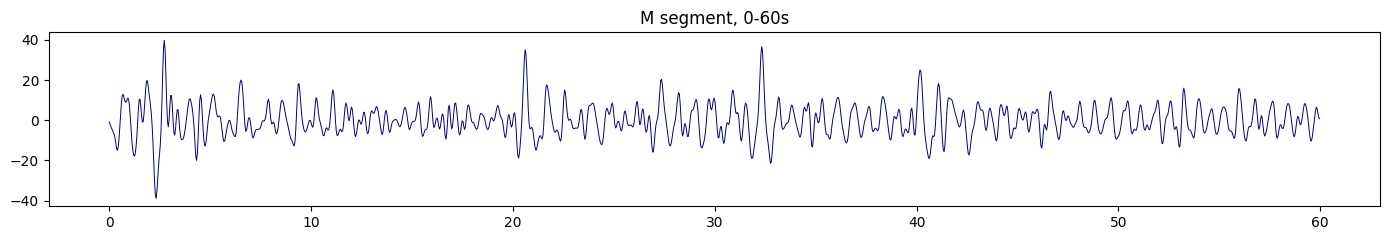

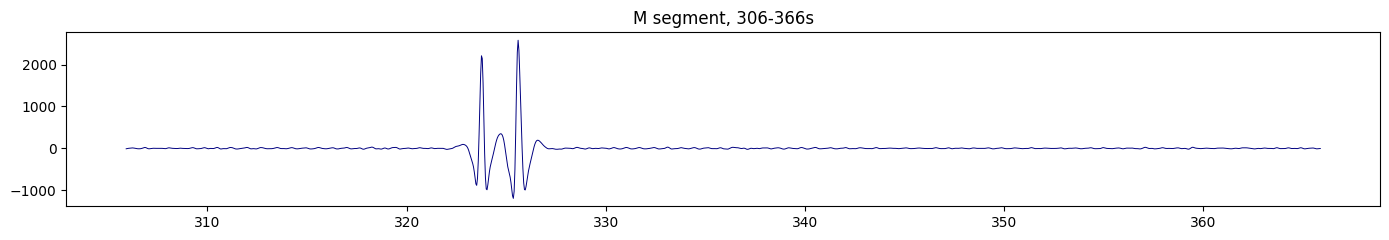

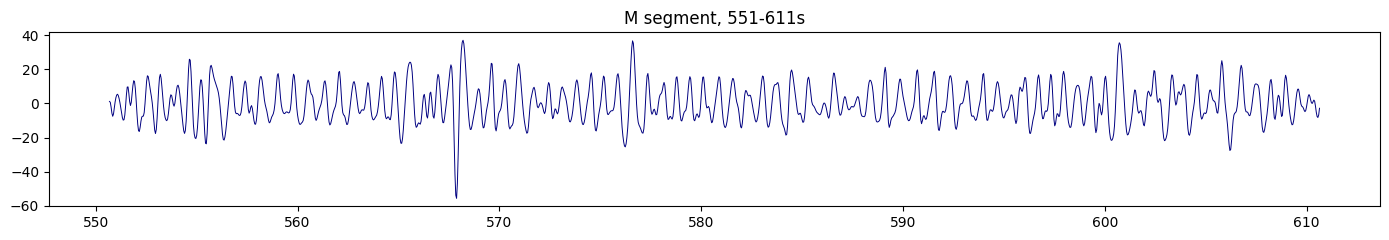

In [279]:
PARTICIPANT = "23_Distrust Priming"
SEG_COL     = "Reliability"     # <- set to the column that actually holds HH/LL/M
BAD_SEG     = "M"

import numpy as np, matplotlib.pyplot as plt
g    = _get_group_df(PARTICIPANT)
raw  = g[g[SEG_COL].astype(str) == BAD_SEG][VALIDATE_PPG_COL].dropna().values.astype(float)
clean = nk.ppg_clean(raw, sampling_rate=SAMPLING_RATE, method="langevin2021")

print(f"{BAD_SEG}: {len(clean)/SAMPLING_RATE:.0f}s, peak |amp| = {np.max(np.abs(clean)):.0f} "
      f"(typical pulse is ~50-100)")
thr    = 10 * np.median(np.abs(clean))           # 10x the normal level
spikes = np.where(np.abs(clean) > thr)[0]
if len(spikes):
    print(f"{len(spikes)} samples exceed 10x median, "
          f"spanning {spikes[0]/SAMPLING_RATE:.0f}-{spikes[-1]/SAMPLING_RATE:.0f}s")

for frac in [0.0, 0.5, 0.9]:                      # start, middle, end of M
    a = int(frac * len(clean)); b = min(len(clean), a + 60 * SAMPLING_RATE)
    plt.figure(figsize=(14, 2.5))
    plt.plot(np.arange(a, b) / SAMPLING_RATE, clean[a:b], lw=0.7, color="navy")
    plt.title(f"{BAD_SEG} segment, {a/SAMPLING_RATE:.0f}-{b/SAMPLING_RATE:.0f}s")
    plt.tight_layout(); plt.show()

In [280]:
from scipy.ndimage import label as cc_label

def artifact_mask(clean, sampling_rate, k=8, pad_s=2.0, min_floor=None):
    """Mask artifact regions: samples more than k robust-SDs (MAD) from the
    median, grouped into contiguous events, each padded by pad_s seconds."""
    med = np.median(clean)
    mad = np.median(np.abs(clean - med)) * 1.4826      # robust std estimate
    if mad == 0:
        return np.zeros(len(clean), bool)
    thresh = k * mad
    if min_floor is not None:
        thresh = max(thresh, min_floor)
    flag = np.abs(clean - med) > thresh
    lab, n = cc_label(flag)
    pad = int(pad_s * sampling_rate)
    mask = np.zeros(len(clean), bool)
    for i in range(1, n + 1):
        idx = np.where(lab == i)[0]
        mask[max(0, idx[0] - pad): min(len(clean), idx[-1] + pad + 1)] = True
    return mask

In [281]:
def detect_segment(raw_segment, sampling_rate, method="langevin2021", min_run_s=20):
    """Mask artifacts, re-detect on each clean run >= min_run_s, pool the beats.
    Returns dict with peak count, IBIs, and physiological fraction (QC gate)."""
    clean = nk.ppg_clean(raw_segment, sampling_rate=sampling_rate, method=method)
    mask  = artifact_mask(clean, sampling_rate)

    raw_masked = np.asarray(raw_segment, float).copy()
    raw_masked[mask] = np.nan
    idx = np.where(~np.isnan(raw_masked))[0]
    if len(idx) == 0:
        return dict(n_peaks=0, ibi=np.array([]), pct_phys=0.0, masked_s=mask.sum()/sampling_rate)

    splits = np.where(np.diff(idx) > 1)[0]
    starts = np.r_[idx[0], idx[splits + 1]]
    ends   = np.r_[idx[splits], idx[-1]]

    all_ibi, n_peaks = [], 0
    for s, e in zip(starts, ends):
        if (e - s) < min_run_s * sampling_rate:
            continue
        _, pk = _clean_and_findpeaks(raw_segment[s:e + 1], sampling_rate, method)
        n_peaks += len(pk)
        all_ibi.append(np.diff(pk) / sampling_rate * 1000)

    ibi = np.concatenate(all_ibi) if all_ibi else np.array([])
    ok  = (ibi >= 333) & (ibi <= 1500)
    return dict(n_peaks=n_peaks, ibi=ibi,
                pct_phys=100 * ok.mean() if len(ibi) else 0.0,
                masked_s=mask.sum() / sampling_rate)

In [282]:
SEG_COL       = "Reliability"
TASK_SEGMENTS = ["HH", "LL", "M"]
QC_THRESHOLD  = 80   # flag any segment below this % physiological

for label in all_results:               # every participant/condition group
    g = _get_group_df(label)
    for seg in TASK_SEGMENTS:
        raw = g[g[SEG_COL].astype(str) == seg][VALIDATE_PPG_COL].dropna().values.astype(float)
        if len(raw) < 20 * SAMPLING_RATE:
            print(f"{label}/{seg}: too short / missing"); continue
        r = detect_segment(raw, SAMPLING_RATE)
        flag = "" if r["pct_phys"] >= QC_THRESHOLD else "  <-- FLAG (inspect / try RED-IR / IS)"
        hr = 60000 / np.mean(r["ibi"][(r["ibi"]>=333)&(r["ibi"]<=1500)]) if r["n_peaks"] else float("nan")
        print(f"{label}/{seg}: {r['n_peaks']:4d} peaks  {r['pct_phys']:3.0f}% phys  "
              f"HR {hr:4.0f}  (masked {r['masked_s']:.0f}s){flag}")

23_Distrust Priming/HH:  831 peaks  100% phys  HR   82  (masked 4s)
23_Distrust Priming/LL:  467 peaks   95% phys  HR   78  (masked 111s)
23_Distrust Priming/M:  634 peaks   97% phys  HR   77  (masked 74s)


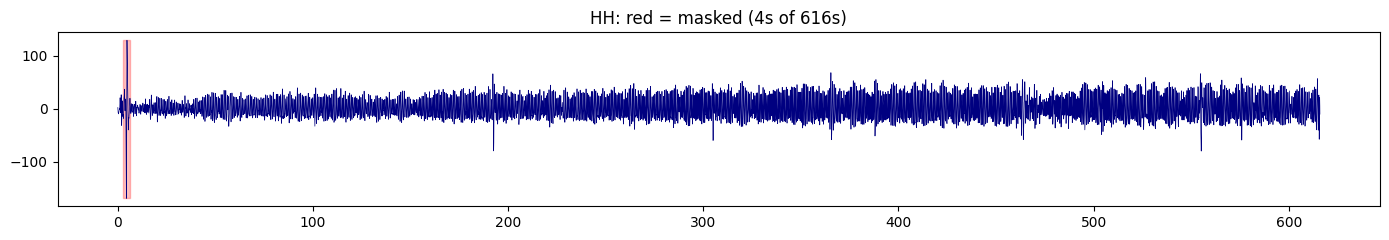

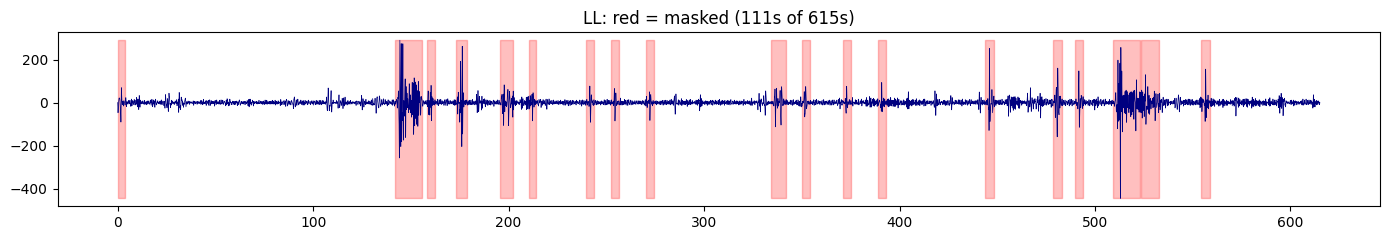

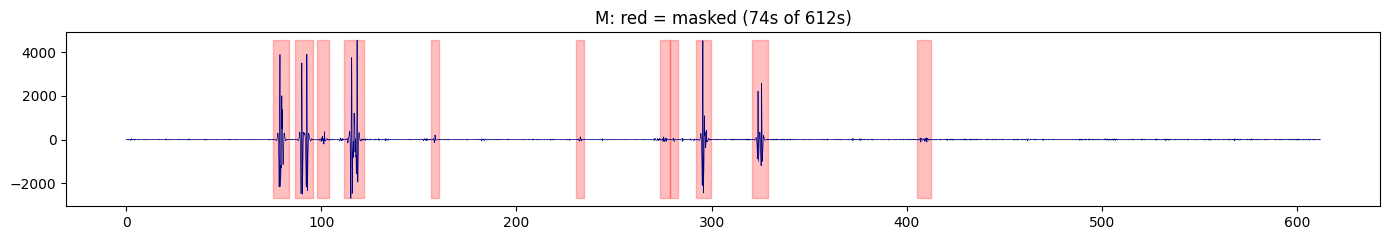

In [283]:
for seg in ["HH", "LL", "M"]:
    g   = _get_group_df("23_Distrust Priming")
    raw = g[g["Reliability"].astype(str) == seg][VALIDATE_PPG_COL].dropna().values.astype(float)
    clean = nk.ppg_clean(raw, sampling_rate=SAMPLING_RATE, method="langevin2021")
    m = artifact_mask(clean, SAMPLING_RATE)
    t = np.arange(len(clean)) / SAMPLING_RATE
    plt.figure(figsize=(14, 2.5))
    plt.plot(t, clean, lw=0.5, color="navy")
    plt.fill_between(t, clean.min(), clean.max(), where=m, color="red", alpha=0.25)
    plt.title(f"{seg}: red = masked ({m.sum()/SAMPLING_RATE:.0f}s of {len(clean)/SAMPLING_RATE:.0f}s)")
    plt.tight_layout(); plt.show()

In [284]:
def validate_segment(label, seg, seg_col="Reliability", sampling_rate=25,
                     ppg_col=VALIDATE_PPG_COL, tol_ms=PEAK_TOL_MS):
    g   = _get_group_df(label)
    raw = g[g[seg_col].astype(str) == seg][ppg_col].dropna().values.astype(float)
    if len(raw) < sampling_rate * 20:
        print(f"[{label}/{seg}] too short -- skipped"); return
    tol = tol_ms / 1000 * sampling_rate
    _, pe = _clean_and_findpeaks(raw, sampling_rate, "elgendi")
    _, pl = _clean_and_findpeaks(raw, sampling_rate, "langevin2021")
    matched, dropped, extra = _match_peaks(pe, pl, tol)
    def phys(p):
        ibi = np.diff(p) / sampling_rate * 1000; ok = (ibi >= 333) & (ibi <= 1500)
        return 100 * ok.mean() if len(ibi) else 0
    agree = 100 * len(matched) / len(pe) if len(pe) else float("nan")
    print(f"[{label}/{seg}] elgendi {len(pe)}pk/{phys(pe):.0f}%phys   "
          f"langevin {len(pl)}pk/{phys(pl):.0f}%phys   "
          f"agree {agree:.0f}%   dropped {len(dropped)}   extra {len(extra)}")

for seg in ["HH", "LL"]:        # the clean segments; add M once it's masked/fixed
    validate_segment("23_Distrust Priming", seg, seg_col=SEG_COL)

[23_Distrust Priming/HH] elgendi 681pk/92%phys   langevin 838pk/100%phys   agree 96%   dropped 29   extra 186
[23_Distrust Priming/LL] elgendi 519pk/75%phys   langevin 673pk/90%phys   agree 85%   dropped 77   extra 231


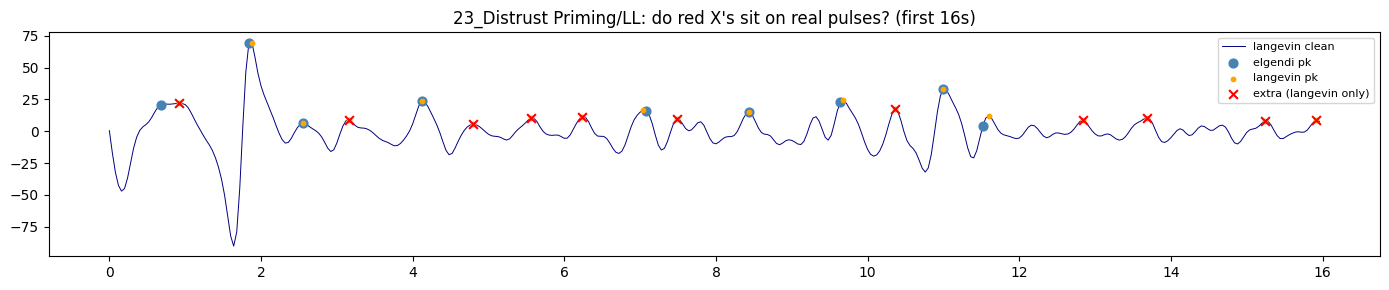

In [285]:
def inspect_extras(label, seg, seg_col="Reliability", sampling_rate=25,
                   ppg_col=VALIDATE_PPG_COL, n_show=400):
    import numpy as np, matplotlib.pyplot as plt
    g   = _get_group_df(label)
    raw = g[g[seg_col].astype(str) == seg][ppg_col].dropna().values.astype(float)
    clean_l = nk.ppg_clean(raw, sampling_rate=sampling_rate, method="langevin2021")
    _, pe = _clean_and_findpeaks(raw, sampling_rate, "elgendi")
    _, pl = _clean_and_findpeaks(raw, sampling_rate, "langevin2021")
    matched, dropped, extra = _match_peaks(pe, pl, PEAK_TOL_MS/1000*sampling_rate)

    a, b = 0, min(n_show, len(clean_l))
    t = np.arange(a, b) / sampling_rate
    plt.figure(figsize=(14, 3))
    plt.plot(t, clean_l[a:b], color="navy", lw=0.7, label="langevin clean")
    for arr, c, lab, mk in [(pe, "steelblue", "elgendi pk", "o"),
                            (pl, "orange", "langevin pk", "."),
                            (np.array(extra), "red", "extra (langevin only)", "x")]:
        arr = np.asarray(arr, int); arr = arr[(arr >= a) & (arr < b)]
        plt.scatter(arr/sampling_rate, clean_l[arr], c=c, marker=mk, s=40, label=lab, zorder=5)
    plt.title(f"{label}/{seg}: do red X's sit on real pulses? (first {n_show/sampling_rate:.0f}s)")
    plt.legend(fontsize=8, loc="upper right"); plt.tight_layout(); plt.show()

inspect_extras("23_Distrust Priming", "LL")

In [286]:
import os, glob, re
import numpy as np, pandas as pd

# ---------- CONFIG ----------
DATA_ROOT     = "Data"                         # folder holding 4_Data, 6_Data, ...
CHANNELS      = ["PPG_GRN_C", "PPG_GRN_I"]     # stream identifiers (file name and/or column)
SAMPLING_RATE = 25
SIGNAL_COL    = None    # set to the exact column name once you know it; None = auto-detect
MIN_RUN_S     = 20
QC_THRESHOLD  = 80      # % physiological below which a stream gets flagged
# ----------------------------

def list_sessions(root):
    subs = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
    def sid(d):
        m = re.match(r"(\d+)", d); return int(m.group(1)) if m else 1e9
    return sorted(subs, key=sid)

def find_channel_file(session_dir, channel):
    cands = glob.glob(os.path.join(session_dir, "*.csv"))
    cl = channel.lower()
    exact = [c for c in cands if os.path.splitext(os.path.basename(c))[0].lower() == cl]
    if exact: return exact[0]
    hits = [c for c in cands if cl in os.path.basename(c).lower()]
    return sorted(hits, key=lambda x: len(os.path.basename(x)))[0] if hits else None

def pick_signal_column(df, channel):
    if SIGNAL_COL and SIGNAL_COL in df.columns: return SIGNAL_COL
    if channel in df.columns:                   return channel
    num = df.select_dtypes("number").columns.tolist()
    num = [c for c in num if not re.search(r"time|stamp|date|index", str(c), re.I)]
    hint = [c for c in num if re.search(r"pg|ppg|grn|green", str(c), re.I)]
    if hint: return hint[0]
    return num[-1] if num else None

# --- Discovery: inspect the first session so you can confirm column choice ---
sessions = list_sessions(DATA_ROOT)
print(f"Found {len(sessions)} sessions: {sessions[:8]}{' ...' if len(sessions) > 8 else ''}\n")

s0 = os.path.join(DATA_ROOT, sessions[0])
for ch in CHANNELS:
    f = find_channel_file(s0, ch)
    if f is None:
        print(f"[{sessions[0]}] {ch}: NO FILE matched"); continue
    df = pd.read_csv(f, nrows=5)
    col = pick_signal_column(df, ch)
    print(f"[{sessions[0]}] {ch}")
    print(f"   file:    {os.path.basename(f)}")
    print(f"   columns: {df.columns.tolist()}")
    print(f"   -> using column: '{col}'\n")

Found 51 sessions: ['4_Data', '6_Data', '7_Data', '10_Data', '12_Data', '14_Data', '15_Data', '16_Data'] ...

[4_Data] PPG_GRN_C
   file:    PPG_GRN_C.csv
   columns: ['timestamp', 'value']
   -> using column: 'value'

[4_Data] PPG_GRN_I
   file:    PPG_GRN_I.csv
   columns: ['timestamp', 'value']
   -> using column: 'value'



In [287]:
# Requires the helper functions from earlier: _clean_and_findpeaks, artifact_mask (MAD version), detect_segment
for fn in ["_clean_and_findpeaks", "artifact_mask", "detect_segment"]:
    assert fn in globals(), f"Define {fn} first (artifact_mask must be the MAD version)."

def qc_one(path, channel, sampling_rate=SAMPLING_RATE):
    df  = pd.read_csv(path)
    col = pick_signal_column(df, channel)
    if col is None:
        return dict(error="no signal column")
    raw = df[col].values.astype(float)
    raw = raw[~np.isnan(raw)]
    dur = len(raw) / sampling_rate
    if dur < MIN_RUN_S:
        return dict(error=f"too short ({dur:.0f}s)")
    r   = detect_segment(raw, sampling_rate, method="langevin2021", min_run_s=MIN_RUN_S)
    ibi = r["ibi"]; ok = (ibi >= 333) & (ibi <= 1500)
    hr  = 60000 / np.mean(ibi[ok]) if ok.sum() else float("nan")
    return dict(total_s=dur, retained_s=dur - r["masked_s"], masked_s=r["masked_s"],
                pct_masked=100 * r["masked_s"] / dur,
                n_peaks=r["n_peaks"], pct_phys=r["pct_phys"], hr=hr)

rows = []
for sess in sessions:
    sdir = os.path.join(DATA_ROOT, sess)
    for ch in CHANNELS:
        f = find_channel_file(sdir, ch)
        if f is None:
            rows.append(dict(session=sess, channel=ch, error="no file")); continue
        try:
            res = qc_one(f, ch)
        except Exception as e:
            res = dict(error=str(e)[:60])
        rows.append(dict(session=sess, channel=ch, **res))
        tag = res.get("error") or (
            f"{res['n_peaks']:4d}pk  {res['pct_phys']:3.0f}%phys  HR {res['hr']:4.0f}  "
            f"masked {res['masked_s']:4.0f}s ({res['pct_masked']:2.0f}%)"
            + ("" if res['pct_phys'] >= QC_THRESHOLD else "  <-- FLAG"))
        print(f"{sess:>10} / {ch:11}: {tag}")

qc = pd.DataFrame(rows)
qc.to_csv("ppg_quality_scan.csv", index=False)
print(f"\nSaved -> ppg_quality_scan.csv  ({len(qc)} rows)")

# Worst sessions first, so problems surface immediately
if "pct_phys" in qc.columns:
    view = qc.dropna(subset=["pct_phys"]).sort_values("pct_phys")
    print("\nLowest-quality streams:")
    print(view[["session","channel","pct_phys","pct_masked","n_peaks","hr"]].head(12).to_string(index=False))

    4_Data / PPG_GRN_C  : 2172pk   95%phys  HR   77  masked  653s (23%)
    4_Data / PPG_GRN_I  : 3090pk   98%phys  HR   82  masked  307s (11%)
    6_Data / PPG_GRN_C  : 4514pk   98%phys  HR   91  masked   37s ( 1%)
    6_Data / PPG_GRN_I  : 3358pk   95%phys  HR   67  masked  153s ( 5%)
    7_Data / PPG_GRN_C  : 4579pk   97%phys  HR   73  masked 1457s (23%)
    7_Data / PPG_GRN_I  : 3760pk   95%phys  HR   64  masked 1888s (30%)
   10_Data / PPG_GRN_C  : 2399pk   93%phys  HR   64  masked  565s (16%)
   10_Data / PPG_GRN_I  : 1321pk   84%phys  HR   71  masked 1568s (46%)
   12_Data / PPG_GRN_C  : 5900pk   99%phys  HR   81  masked    9s ( 0%)
   12_Data / PPG_GRN_I  : 4897pk   95%phys  HR   70  masked    0s ( 0%)
   14_Data / PPG_GRN_C  : 2257pk   95%phys  HR   70  masked  536s (18%)
   14_Data / PPG_GRN_I  : 2815pk   97%phys  HR   74  masked  362s (12%)
   15_Data / PPG_GRN_C  : 2702pk   94%phys  HR   73  masked  641s (20%)
   15_Data / PPG_GRN_I  : 1374pk   93%phys  HR   70  masked 1426

In [288]:
PARTICIPANT = "23_Distrust Priming"
SEG_COL     = "Reliability"
SEGMENTS    = ["HH", "LL", "M"]

import numpy as np

print(f"{'seg':>4} | {'stage':<22} | {'peaks':>6} {'%phys':>6} {'RMSSD':>8} {'HR':>5} | {'kept_s':>7} {'masked_s':>8} {'%masked':>7}")
print("-"*92)

for seg in SEGMENTS:
    g   = _get_group_df(PARTICIPANT)
    raw = g[g[SEG_COL].astype(str) == seg][VALIDATE_PPG_COL].dropna().values.astype(float)
    if len(raw) < 20*SAMPLING_RATE:
        print(f"{seg:>4} | too short"); continue
    total_s = len(raw) / SAMPLING_RATE

    # --- VALIDATED PATH: detect + Kubios, NO masking (uses full segment) ---
    _, peaks_raw = _clean_and_findpeaks(raw, SAMPLING_RATE, "langevin2021")
    s_raw  = _stats(peaks_raw, SAMPLING_RATE)
    peaks_k = kubios_correct(peaks_raw, SAMPLING_RATE)
    s_kub  = _stats(peaks_k, SAMPLING_RATE)

    # --- CUSTOM PATH: MAD mask + detect on clean runs ---
    r = detect_segment(raw, SAMPLING_RATE, method="langevin2021")
    ibi = r["ibi"]; ok = (ibi >= 333) & (ibi <= 1500)
    s_mad = dict(n=r["n_peaks"], pct_phys=r["pct_phys"],
                 rmssd=np.sqrt(np.mean(np.diff(ibi[ok])**2)) if ok.sum() > 2 else np.nan,
                 hr=60000/np.mean(ibi[ok]) if ok.sum() else np.nan)
    masked_s   = r["masked_s"]
    kept_s     = total_s - masked_s
    pct_masked = 100 * masked_s / total_s

    rows = [
        ("1. detect only",          s_raw, total_s, 0.0,      0.0),
        ("2. + Kubios (validated)", s_kub, total_s, 0.0,      0.0),
        ("3. MAD mask (custom)",    s_mad, kept_s,  masked_s, pct_masked),
    ]
    for name, s, kept, msk, pct in rows:
        print(f"{seg:>4} | {name:<22} | {s['n']:>6} {s['pct_phys']:>6.0f} "
              f"{s['rmssd'] if not np.isnan(s['rmssd']) else 0:>8.1f} "
              f"{s['hr'] if not np.isnan(s['hr']) else 0:>5.0f} | "
              f"{kept:>7.0f} {msk:>8.0f} {pct:>6.0f}%")
    print(f"{seg:>4} | (segment total: {total_s:.0f}s)")
    print("-"*92)

 seg | stage                  |  peaks  %phys    RMSSD    HR |  kept_s masked_s %masked
--------------------------------------------------------------------------------------------


KeyError: 'Reliability'

In [220]:
import numpy as np, pandas as pd

FULL_PATH = "aoi_physio_survey.csv"
CHANNELS  = ["PPG_GRN_C", "PPG_GRN_IS"]
ID_COL    = "ID"
GROUP_BY  = [ID_COL]          # -> ["ID","Condition"] to split by priming too

if "df_full" not in globals():
    print(f"Loading {FULL_PATH} ...")
    df_full = pd.read_csv(FULL_PATH)
print(f"df_full: {df_full.shape[0]:,} rows x {df_full.shape[1]} cols")

seg_col = None
for c in df_full.columns:
    if {"HH", "LL", "M"} & set(df_full[c].dropna().astype(str).unique()):
        seg_col = c; break
print(f"segment column: {seg_col!r}\n")

def _phys(ibi):
    ok = (ibi >= 333) & (ibi <= 1500)
    return 100 * ok.mean() if len(ibi) else 0.0

def scan_id_channel(sub, ch, sr=SAMPLING_RATE):
    if ch not in sub.columns or not sub[ch].notna().any():
        return None
    total_s = sub[ch].notna().sum() / sr

    if seg_col and seg_col in sub.columns:
        units = [sub[sub[seg_col].astype(str) == s][ch].dropna().values.astype(float)
                 for s in ["HH", "LL", "M"] if (sub[seg_col].astype(str) == s).any()]
    else:
        units = [sub[ch].dropna().values.astype(float)]

    ibi_raw, ibi_kub, ibi_mad = [], [], []
    n_raw = n_kub = n_mad = 0
    masked_s = 0.0
    kub_failed = False

    for raw in units:
        if len(raw) < 20 * sr:
            continue
        # 1. detect only
        _, pk = _clean_and_findpeaks(raw, sr, "langevin2021")
        ibi_raw.append(np.diff(pk) / sr * 1000); n_raw += len(pk)
        # 2. + Kubios (validated), defensively
        try:
            pkk = kubios_correct(pk, sr)
        except Exception:
            pkk = pk; kub_failed = True
        ibi_kub.append(np.diff(pkk) / sr * 1000); n_kub += len(pkk)
        # 3. MAD mask (custom)
        r = detect_segment(raw, sr, method="langevin2021")
        ibi_mad.append(r["ibi"]); n_mad += r["n_peaks"]; masked_s += r["masked_s"]

    cat = lambda L: np.concatenate(L) if L else np.array([])
    ibi_raw, ibi_kub, ibi_mad = cat(ibi_raw), cat(ibi_kub), cat(ibi_mad)
    ok = (ibi_mad >= 333) & (ibi_mad <= 1500)
    hr = 60000 / np.mean(ibi_mad[ok]) if ok.sum() else np.nan

    return dict(total_s=total_s, masked_s=masked_s,
                pct_masked=100 * masked_s / total_s if total_s else np.nan,
                n_raw=n_raw, phys_raw=_phys(ibi_raw),
                n_kub=n_kub, phys_kub=_phys(ibi_kub),
                n_mad=n_mad, phys_mad=_phys(ibi_mad),
                hr_mad=hr, kub_failed=kub_failed)

rows = []
groups = df_full.groupby(GROUP_BY, sort=False)
print(f"Scanning {len(groups)} groups x {len(CHANNELS)} channels ...\n")
print(f"{'ID/channel':>20} | {'detect':>12} | {'+Kubios':>12} | {'MAD':>12} | {'masked':>12}")
print("-"*82)
for gkey, sub in groups:
    gid = gkey if not isinstance(gkey, tuple) else "_".join(map(str, gkey))
    for ch in CHANNELS:
        res = scan_id_channel(sub, ch)
        if res is None:
            rows.append(dict(ID=gid, channel=ch, note="missing/all-NaN")); continue
        rows.append(dict(ID=gid, channel=ch, **res))
        kf = "!" if res["kub_failed"] else " "
        print(f"{str(gid)[:11]+'/'+ch.replace('PPG_GRN_',''):>20} | "
              f"{res['n_raw']:4d}pk {res['phys_raw']:3.0f}% | "
              f"{res['n_kub']:4d}pk {res['phys_kub']:3.0f}%{kf}| "
              f"{res['n_mad']:4d}pk {res['phys_mad']:3.0f}% | "
              f"{res['masked_s']:4.0f}s {res['pct_masked']:2.0f}%")

qc = pd.DataFrame(rows)
qc.to_csv("mad_kubios_scan_by_id.csv", index=False)
print(f"\nSaved -> mad_kubios_scan_by_id.csv  ({len(qc)} rows)")

# --- Decision summaries ---
if "phys_mad" in qc.columns:
    v = qc.dropna(subset=["phys_mad"])
    print(f"\nMean physiological fraction:  detect {v['phys_raw'].mean():.0f}%  "
          f"+Kubios {v['phys_kub'].mean():.0f}%  MAD {v['phys_mad'].mean():.0f}%")
    print(f"MAD masking: median {v['pct_masked'].median():.1f}%  "
          f"mean {v['pct_masked'].mean():.1f}%  max {v['pct_masked'].max():.1f}%")
    # Where does Kubios alone suffice (gets within 3% of MAD)?
    close = v[(v['phys_kub'] >= v['phys_mad'] - 3)]
    print(f"\nIDs where Kubios alone ~matches MAD (within 3%): {len(close)} of {len(v)}")
    print("  -> for these, the validated path is enough; no masking needed")
    print("\nLargest MAD advantage over Kubios (top 10 -- masking earns its keep here):")
    v = v.assign(mad_gain=v['phys_mad'] - v['phys_kub'])
    print(v.sort_values('mad_gain', ascending=False)
          [["ID","channel","phys_raw","phys_kub","phys_mad","pct_masked","mad_gain"]]
          .head(10).round(1).to_string(index=False))

df_full: 4,058,617 rows x 80 cols
segment column: 'Reliability'

Scanning 52 groups x 2 channels ...

          ID/channel |       detect |      +Kubios |          MAD |       masked
----------------------------------------------------------------------------------
                 4/C |  514pk  62% |  536pk  56% | 1512pk  96% |  317s 11%
                4/IS | 1436pk  92% | 1480pk  92% | 1849pk  98% |  229s  8%
                 6/C | 2793pk  99% | 3050pk 100% | 2788pk  99% |    4s  0%
                6/IS | 1485pk  90% | 1536pk  92% | 1911pk  96% |   23s  1%
                 7/C | 2969pk  98% | 3066pk 100% | 2977pk  98% |   15s  0%
                7/IS | 1751pk  84% | 1808pk  86% | 2085pk  96% |  219s  3%
                10/C | 1956pk  84% | 2059pk  86% | 1763pk  93% |  380s 11%
               10/IS | 1607pk  78% | 1691pk  74% |  957pk  84% |  848s 25%
                12/C | 3266pk  99% | 3537pk 100% | 3266pk  99% |    9s  0%
               12/IS | 2726pk  95% | 2911pk 100% | 2726pk  

In [221]:
v = qc.dropna(subset=["phys_mad"]).copy()
v["mad_minus_kub"] = v["phys_mad"] - v["phys_kub"]
worse = v[v["mad_minus_kub"] < 0]
print(f"{len(worse)} streams where MAD < Kubios")
print(worse[["ID","channel","pct_masked","phys_kub","phys_mad","mad_minus_kub"]]
      .sort_values("mad_minus_kub").round(1).to_string(index=False))
# Is MAD-worse associated with more masking?
print(f"\nmean pct_masked where MAD worse: {worse['pct_masked'].mean():.1f}%")
print(f"mean pct_masked where MAD >= Kubios: {v[v['mad_minus_kub']>=0]['pct_masked'].mean():.1f}%")

46 streams where MAD < Kubios
ID    channel  pct_masked  phys_kub  phys_mad  mad_minus_kub
45 PPG_GRN_IS         0.0      99.3      93.9           -5.4
12 PPG_GRN_IS         0.0      99.9      94.8           -5.1
47 PPG_GRN_IS         0.3      98.1      93.9           -4.2
20  PPG_GRN_C         0.5      99.5      95.5           -4.0
29  PPG_GRN_C         0.0      94.3      91.1           -3.2
31  PPG_GRN_C         0.1      93.5      90.7           -2.8
24 PPG_GRN_IS         7.7      98.3      95.6           -2.7
43 PPG_GRN_IS         1.2     100.0      97.3           -2.6
43  PPG_GRN_C         0.7     100.0      97.7           -2.3
13 PPG_GRN_IS         0.6      96.8      94.4           -2.3
14 PPG_GRN_IS         1.4      99.3      97.0           -2.3
18  PPG_GRN_C         0.0      92.0      89.7           -2.3
13  PPG_GRN_C         0.7      99.8      97.6           -2.2
49 PPG_GRN_IS         0.1      95.0      92.9           -2.1
50  PPG_GRN_C         0.2      95.6      93.8          

In [250]:
"""
compare_csvs.py — diagnose why two large CSVs have different row counts.

Drop this into a notebook cell. It compares two files structurally without
needing them to fit comparisons in your head: shapes, columns, dtypes, where
the row counts diverge, duplicate rows, all-NaN rows, and (if an ID/segment
column exists) per-group row counts so you can see exactly which groups gained
or lost rows.
"""
import pandas as pd
import numpy as np


def compare_csvs(path_a, path_b, key_cols=None, sample_mismatch=5):
    """
    Compare two CSV files and report where they differ.

    Parameters
    ----------
    path_a, path_b : str
        Paths to the two CSVs (A = reference, e.g. the merged file;
        B = the one with extra rows, e.g. the cleaned output).
    key_cols : list[str] or None
        Columns that identify a logical unit (e.g. ["ID", "Condition"]).
        If given, the function reports per-group row-count differences so you
        can localise which groups gained/lost rows. Auto-detected if None.
    sample_mismatch : int
        How many example mismatching rows to show.
    """
    print(f"A = {path_a}")
    print(f"B = {path_b}\n")

    a = pd.read_csv(path_a)
    b = pd.read_csv(path_b)

    # ---- 1. shapes ----
    print("=" * 60)
    print("1. SHAPES")
    print(f"   A: {a.shape[0]:,} rows x {a.shape[1]} cols")
    print(f"   B: {b.shape[0]:,} rows x {b.shape[1]} cols")
    print(f"   row difference (B - A): {b.shape[0] - a.shape[0]:,}")

    # ---- 2. columns ----
    print("\n2. COLUMNS")
    only_a = [c for c in a.columns if c not in b.columns]
    only_b = [c for c in b.columns if c not in a.columns]
    print(f"   only in A: {only_a}")
    print(f"   only in B: {only_b}")
    shared = [c for c in a.columns if c in b.columns]
    print(f"   shared: {len(shared)} columns")

    # ---- 3. duplicate rows within each file ----
    print("\n3. DUPLICATE ROWS (fully identical rows)")
    dup_a = a.duplicated().sum()
    dup_b = b.duplicated().sum()
    print(f"   A: {dup_a:,} duplicate rows")
    print(f"   B: {dup_b:,} duplicate rows")
    if dup_b > dup_a:
        print(f"   -> B has {dup_b - dup_a:,} MORE duplicate rows than A")

    # ---- 4. all-NaN rows ----
    print("\n4. ALL-NaN / EMPTY ROWS")
    empty_a = a.isna().all(axis=1).sum()
    empty_b = b.isna().all(axis=1).sum()
    print(f"   A: {empty_a:,} fully-empty rows")
    print(f"   B: {empty_b:,} fully-empty rows")

    # ---- 5. auto-detect key columns if not given ----
    if key_cols is None:
        cand = []
        for name in ["ID", "Condition", "Team ID"]:
            if name in shared:
                cand.append(name)
        # also grab the reliability/segment col if present
        for c in shared:
            if {"HH", "LL", "M"} & set(a[c].dropna().astype(str).unique()[:50]):
                cand.append(c); break
        key_cols = cand if cand else None
    if key_cols:
        key_cols = [c for c in key_cols if c in shared]
    print(f"\n5. PER-GROUP ROW COUNTS  (keys: {key_cols})")

    if key_cols:
        ca = a.groupby(key_cols, dropna=False).size().rename("rows_A")
        cb = b.groupby(key_cols, dropna=False).size().rename("rows_B")
        merged = pd.concat([ca, cb], axis=1).fillna(0).astype(int)
        merged["diff"] = merged["rows_B"] - merged["rows_A"]
        changed = merged[merged["diff"] != 0].sort_values("diff", ascending=False)
        if len(changed):
            print(f"   {len(changed)} group(s) differ in row count:")
            print(changed.to_string())
            print(f"\n   total extra rows accounted for: {changed['diff'].sum():,}")
        else:
            print("   No per-group row-count differences "
                  "(extra rows are NOT explained by these keys).")
    else:
        print("   No usable key columns found; skipping per-group comparison.")

    # ---- 6. if same shape & keys, find value mismatches ----
    if a.shape == b.shape and key_cols:
        print("\n6. VALUE MISMATCHES (same shape — comparing aligned rows)")
        # align by sorting on keys + a time col if available
        time_col = next((c for c in ["timestamp", "time", "unix"] if c in shared), None)
        sort_on = key_cols + ([time_col] if time_col else [])
        aa = a.sort_values(sort_on).reset_index(drop=True)
        bb = b.sort_values(sort_on).reset_index(drop=True)
        for c in shared:
            if c in (only_a + only_b):
                continue
            neq = (aa[c].fillna("§") != bb[c].fillna("§")).sum()
            if neq:
                print(f"   {c}: {neq:,} differing values")

    return dict(a=a, b=b, key_cols=key_cols)


# ---------------------------------------------------------------
# Usage:
result = compare_csvs("aoi_physio_survey_merged.csv",
                      "aoi_physio_survey.csv")
# ---------------------------------------------------------------

A = aoi_physio_survey_merged.csv
B = aoi_physio_survey.csv

1. SHAPES
   A: 4,023,825 rows x 78 cols
   B: 4,058,617 rows x 80 cols
   row difference (B - A): 34,792

2. COLUMNS
   only in A: []
   only in B: ['Gender_C', 'Gender_IS']
   shared: 78 columns

3. DUPLICATE ROWS (fully identical rows)
   A: 0 duplicate rows
   B: 0 duplicate rows

4. ALL-NaN / EMPTY ROWS
   A: 0 fully-empty rows
   B: 0 fully-empty rows

5. PER-GROUP ROW COUNTS  (keys: ['ID', 'Condition', 'Team ID', 'Reliability'])
   14 group(s) differ in row count:
                                         rows_A  rows_B   diff
ID Condition        Team ID Reliability                       
35 Distrust Priming 35.0    No Video          0   23300  23300
                            HH                0   15399  15399
                            LL                0   15221  15221
                            M                 0   15185  15185
13 Distrust Priming NaN     M                 0   15114  15114
                       

# EDA Cleaning (Preprocessing) + Feature-Extraction Check

Cleans and decomposes electrodermal activity for both devices, writes an
EDA-mergeable file, then extracts SCL/SCR per segment **as a validation check**
(not the final deliverable) to confirm the cleaning is producing sensible signal.

**Input:** `aoi_physio_survey.csv`
**Output:** `aoi_physio_survey_eda_clean.csv` — same rows, with 6 EDA columns:

| column | meaning |
|---|---|
| `EDA_C_clean`, `EDA_IS_clean` | cleaned skin-conductance signal (µS) |
| `EDA_C_tonic`, `EDA_IS_tonic` | tonic component (SCL, slow baseline) |
| `EDA_C_phasic`, `EDA_IS_phasic` | phasic component (SCR drivers, fast responses) |

- Processing is **per recording (ID)** — decomposition never crosses sessions.
- Default NeuroKit decomposition, **no artifact masking** (added later only if the
  validation shows it's needed).
- EmotiBit reports EDA in µS, but uses **dry electrodes**, so absolute SCL may be
  scaled vs. gel-electrode systems — the 1–20 µS range is a *soft* check, not a reject.

In [261]:
import pandas as pd
import numpy as np
import neurokit2 as nk
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [254]:
# --- Configuration ---
IN_PATH   = "aoi_physio_survey.csv"
OUT_PATH  = "aoi_physio_survey_eda_clean.csv"

SAMPLING_RATE = 25                        # Hz
EDA_COLS      = ["EDA_C", "EDA_IS"]
ID_COL        = "ID"

MIN_CLEAN_SAMPLES = SAMPLING_RATE * 10    # need >=10s of valid data to process a run
SCR_AMP_MIN       = 0.01                  # µS — standard SCR amplitude floor (convention)

# SCL plausibility band (soft — dry electrodes may scale this)
SCL_LO, SCL_HI = 1.0, 20.0
# SCR rate plausibility (per minute): ~1-3/min at rest, more under arousal
SCR_RATE_LO, SCR_RATE_HI = 0.3, 25.0

In [255]:
def contiguous_runs(bool_arr):
    """Yield (start, end) ranges for each run of True in a boolean array."""
    idx = np.where(bool_arr)[0]
    if len(idx) == 0:
        return
    splits = np.where(np.diff(idx) > 1)[0]
    starts = np.r_[idx[0], idx[splits + 1]]
    ends   = np.r_[idx[splits] + 1, idx[-1] + 1]
    for s, e in zip(starts, ends):
        yield s, e


def contiguous_blocks(labels):
    """Yield (start, end) ranges for each run of identical labels."""
    labels = np.asarray(labels).astype(str)
    if len(labels) == 0:
        return
    change = np.where(labels[1:] != labels[:-1])[0] + 1
    starts = np.r_[0, change]
    ends   = np.r_[change, len(labels)]
    for s, e in zip(starts, ends):
        yield s, e


def eda_decompose_run(raw_run, sr=SAMPLING_RATE):
    """Clean + decompose one continuous EDA run. Returns (clean, tonic, phasic),
    each aligned to raw_run; NaN-filled if processing fails."""
    n = len(raw_run)
    out = (np.full(n, np.nan), np.full(n, np.nan), np.full(n, np.nan))
    try:
        signals, _ = nk.eda_process(raw_run, sampling_rate=sr)
        return (signals["EDA_Clean"].values,
                signals["EDA_Tonic"].values,
                signals["EDA_Phasic"].values)
    except Exception as e:
        print(f"      eda_process failed on a run: {str(e)[:60]}")
        return out

In [256]:
df = pd.read_csv(IN_PATH)
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} cols")

# segment column (HH/LL/M) — needed for the validation block, not the cleaning
SEG_COL = None
for c in df.columns:
    if {"HH", "LL", "M"} & set(df[c].dropna().astype(str).unique()):
        SEG_COL = c; break

GROUP_COLS = [c for c in [ID_COL, "Condition"] if c in df.columns]
TIME_COL = next((c for c in df.columns
                 if c.lower() in ("timestamp", "time", "unix", "unix_time")), None)

sort_cols = GROUP_COLS + ([TIME_COL] if TIME_COL else [])
if sort_cols:
    df = df.sort_values(sort_cols).reset_index(drop=True)

assert all(c in df.columns for c in EDA_COLS), f"Missing EDA columns: {EDA_COLS}"
print(f"Segment column : {SEG_COL!r}")
print(f"Grouping by     : {GROUP_COLS}")
print(f"Time column     : {TIME_COL!r}")

Loaded 4,058,617 rows x 80 cols
Segment column : 'Reliability'
Grouping by     : ['ID', 'Condition']
Time column     : 'Time'


In [257]:
# initialise output columns
for col in EDA_COLS:
    for suf in ["_clean", "_tonic", "_phasic"]:
        df[col + suf] = np.nan

groups = df.groupby(GROUP_COLS, sort=False) if GROUP_COLS else [("all", df)]
print(f"Processing {len(groups)} recordings...\n")

for gkey, gdf in groups:
    gidx = gdf.index
    for col in EDA_COLS:
        raw = df.loc[gidx, col].values.astype(float)
        valid = ~np.isnan(raw)
        clean  = np.full(len(raw), np.nan)
        tonic  = np.full(len(raw), np.nan)
        phasic = np.full(len(raw), np.nan)

        # decompose each continuous valid run (skip NaN gaps / Replay)
        for s, e in contiguous_runs(valid):
            if (e - s) < MIN_CLEAN_SAMPLES:
                continue
            c, t, p = eda_decompose_run(raw[s:e], SAMPLING_RATE)
            clean[s:e], tonic[s:e], phasic[s:e] = c, t, p

        df.loc[gidx, col + "_clean"]  = clean
        df.loc[gidx, col + "_tonic"]  = tonic
        df.loc[gidx, col + "_phasic"] = phasic

    gname = gkey if not isinstance(gkey, tuple) else "_".join(map(str, gkey))
    print(f"  {gname} done")

Processing 52 recordings...

  4_Distrust Priming done
  6_Distrust Priming done
  7_Trust Priming done
  10_Trust Priming done
  12_Trust Priming done
  13_Distrust Priming done
  14_Trust Priming done
  15_Distrust Priming done
  16_Trust Priming done
  17_Distrust Priming done
  18_Trust Priming done
  19_Distrust Priming done
  20_Trust Priming done
  21_Distrust Priming done
  22_Trust Priming done
  23_Distrust Priming done
  24_Trust Priming done
  25_Distrust Priming done
  26_Trust Priming done
  27_Distrust Priming done
  28_Trust Priming done
  29_Distrust Priming done
  30_Trust Priming done
  31_Distrust Priming done
  32_Trust Priming done
  33_Distrust Priming done
  34_Trust Priming done
  35_Distrust Priming done
  36_Trust Priming done
  37_Distrust Priming done
  38_Trust Priming done
  39_Distrust Priming done
  40_Trust Priming done
  41_Distrust Priming done
  42_Trust Priming done
  43_Distrust Priming done
  44_Trust Priming done
  45_Trust Priming done
  46_Tru

In [258]:
df.to_csv(OUT_PATH, index=False)
print(f"Saved -> {OUT_PATH}  ({df.shape[0]:,} rows x {df.shape[1]} cols)")
print(f"EDA columns now: {[c for c in df.columns if c.startswith('EDA_')]}")

Saved -> aoi_physio_survey_eda_clean.csv  (4,058,617 rows x 86 cols)
EDA columns now: ['EDA_C', 'EDA_IS', 'EDA_C_clean', 'EDA_C_tonic', 'EDA_C_phasic', 'EDA_IS_clean', 'EDA_IS_tonic', 'EDA_IS_phasic']


## Validation: SCL + SCR per segment

Extracts tonic level (SCL) and phasic responses (SCR) per ID × device × segment
**only to check the cleaning worked** — not as the final feature set. Flags:

- **SCL** outside ~1–20 µS (soft; dry electrodes may scale), or non-positive
- **SCR rate** outside ~0.3–25/min (hundreds/min ⇒ noise/motion firing; ~0 ⇒ flat)
- A spike in SCR rate specifically in LL/M would echo the PPG motion finding,
  meaning EDA masking is needed after all.

In [259]:
def scr_features(phasic_run, sr=SAMPLING_RATE, amp_min=SCR_AMP_MIN):
    """Detect SCR peaks on a phasic run; return count and mean amplitude."""
    try:
        _, info = nk.eda_peaks(phasic_run, sampling_rate=sr, amplitude_min=amp_min)
        amps = np.asarray(info.get("SCR_Amplitude", []), float)
        amps = amps[~np.isnan(amps)]
        return len(amps), (np.mean(amps) if len(amps) else np.nan)
    except Exception:
        return 0, np.nan

rows = []
for gkey, gdf in (df.groupby(GROUP_COLS, sort=False) if GROUP_COLS else [("all", df)]):
    gname = gkey if not isinstance(gkey, tuple) else "_".join(map(str, gkey))
    seg_labels = gdf[SEG_COL].values if SEG_COL else np.array(["all"] * len(gdf))
    for col in EDA_COLS:
        tonic  = gdf[col + "_tonic"].values
        phasic = gdf[col + "_phasic"].values
        for bs, be in contiguous_blocks(seg_labels):
            seg = str(seg_labels[bs])
            t_blk = tonic[bs:be]; p_blk = phasic[bs:be]
            valid = ~np.isnan(t_blk)
            dur_s = valid.sum() / SAMPLING_RATE
            if dur_s < 10:
                continue
            mean_scl = np.nanmean(t_blk)
            n_scr, mean_amp = scr_features(p_blk[~np.isnan(p_blk)])
            scr_rate = n_scr / (dur_s / 60) if dur_s else np.nan

            scl_ok = (mean_scl > 0) and (SCL_LO <= mean_scl <= SCL_HI)
            scr_ok = SCR_RATE_LO <= scr_rate <= SCR_RATE_HI
            flag = "" if (scl_ok and scr_ok) else "  <-- CHECK"
            rows.append(dict(group=gname, device=col, segment=seg,
                             dur_s=round(dur_s), mean_scl=round(mean_scl, 2),
                             n_scr=n_scr, scr_per_min=round(scr_rate, 1),
                             mean_scr_amp=round(mean_amp, 3) if not np.isnan(mean_amp) else np.nan,
                             scl_ok=scl_ok, scr_ok=scr_ok))

val = pd.DataFrame(rows)
val.to_csv("eda_validation_by_segment.csv", index=False)
print(f"Saved -> eda_validation_by_segment.csv  ({len(val)} rows)\n")

print("=== Plausibility summary ===")
print(f"SCL in range (1-20 µS): {100*val['scl_ok'].mean():.0f}% of segments")
print(f"SCR rate plausible:     {100*val['scr_ok'].mean():.0f}% of segments")
print(f"\nSCL: median {val['mean_scl'].median():.1f} µS  "
      f"(range {val['mean_scl'].min():.1f}–{val['mean_scl'].max():.1f})")
print(f"SCR rate: median {val['scr_per_min'].median():.1f}/min  "
      f"(range {val['scr_per_min'].min():.1f}–{val['scr_per_min'].max():.1f})")

# the motion-artifact tell: SCR rate by segment type
if SEG_COL and val['segment'].isin(['HH','LL','M']).any():
    print("\nSCR rate by reliability segment (high in LL/M ⇒ possible motion artifact):")
    print(val[val['segment'].isin(['HH','LL','M'])]
          .groupby('segment')['scr_per_min'].median().round(1).to_string())

print("\nSegments flagged for review:")
flagged = val[~(val['scl_ok'] & val['scr_ok'])]
print(f"  {len(flagged)} of {len(val)} segments")
print(flagged.head(12).to_string(index=False))

Saved -> eda_validation_by_segment.csv  (726 rows)

=== Plausibility summary ===
SCL in range (1-20 µS): 3% of segments
SCR rate plausible:     75% of segments

SCL: median 0.1 µS  (range -0.2–65.8)
SCR rate: median 10.2/min  (range 0.1–120.6)

SCR rate by reliability segment (high in LL/M ⇒ possible motion artifact):
segment
HH    8.6
LL    8.3
M     8.6

Segments flagged for review:
  706 of 726 segments
             group device  segment  dur_s  mean_scl  n_scr  scr_per_min  mean_scr_amp  scl_ok  scr_ok
4_Distrust Priming  EDA_C      nan    160      0.03      5          1.9         0.001   False    True
4_Distrust Priming  EDA_C       LL    591      0.05     71          7.2         0.000   False    True
4_Distrust Priming  EDA_C No Video    353      0.03     28          4.8         0.005   False    True
4_Distrust Priming  EDA_C       HH    599      0.05     49          4.9         0.004   False    True
4_Distrust Priming  EDA_C No Video    311      0.03     49          9.4         

## Verify: decomposition on one recording

Plots cleaned EDA with its tonic and phasic split, so you can confirm the tonic
is a smooth slow baseline and the phasic shows Bateman-shaped SCRs (gradual rise
~1 s, decay ~2–5 s) rather than sharp spikes (which would indicate motion).

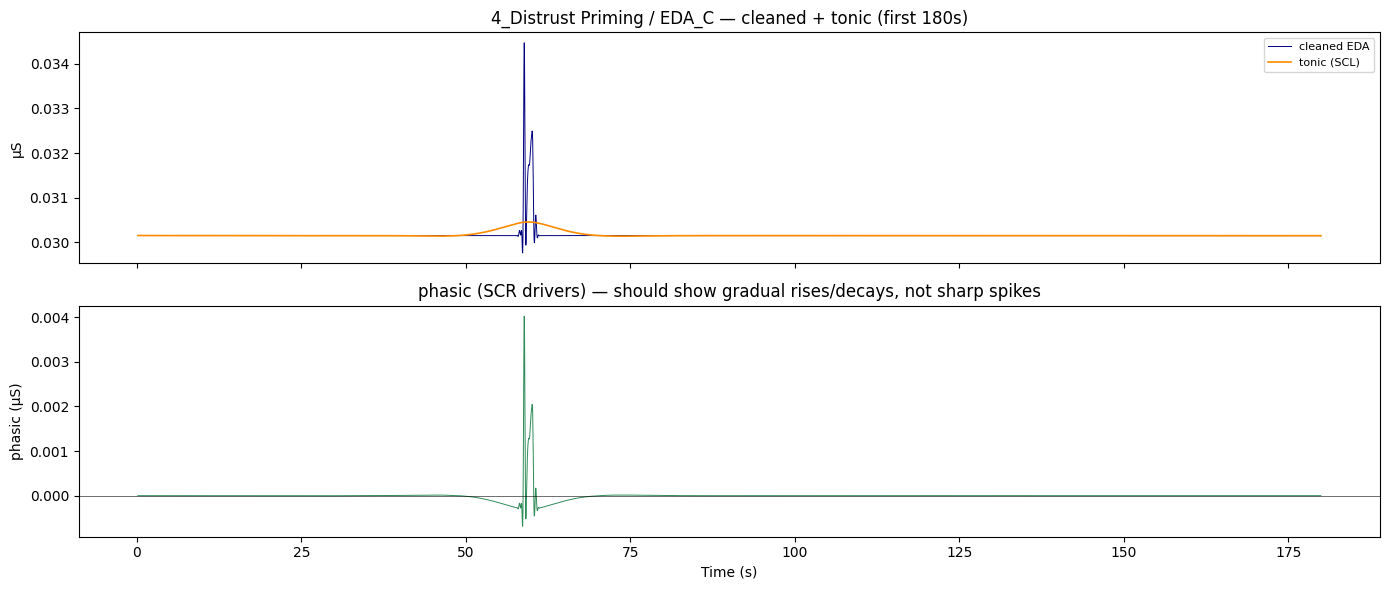

In [260]:
CHECK_GROUP = str(val['group'].iloc[0])   # or set a specific "ID_Condition"
CHECK_COL   = "EDA_C"
WINDOW_S    = 180

if GROUP_COLS:
    mask = pd.Series(True, index=df.index)
    for c, v in zip(GROUP_COLS, CHECK_GROUP.split("_")):
        mask &= df[c].astype(str) == v
    gdf = df[mask]
else:
    gdf = df

n = min(WINDOW_S * SAMPLING_RATE, len(gdf))
t = np.arange(n) / SAMPLING_RATE
clean  = gdf[CHECK_COL + "_clean"].values[:n]
tonic  = gdf[CHECK_COL + "_tonic"].values[:n]
phasic = gdf[CHECK_COL + "_phasic"].values[:n]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(t, clean, color="navy", lw=0.7, label="cleaned EDA")
axes[0].plot(t, tonic, color="darkorange", lw=1.2, label="tonic (SCL)")
axes[0].set_ylabel("µS"); axes[0].legend(fontsize=8)
axes[0].set_title(f"{CHECK_GROUP} / {CHECK_COL} — cleaned + tonic (first {WINDOW_S}s)")

axes[1].plot(t, phasic, color="seagreen", lw=0.7)
axes[1].axhline(0, color="k", lw=0.4)
axes[1].set_ylabel("phasic (µS)"); axes[1].set_xlabel("Time (s)")
axes[1].set_title("phasic (SCR drivers) — should show gradual rises/decays, not sharp spikes")
plt.tight_layout(); plt.show()

In [290]:
raw = pd.read_csv(IN_PATH)
g = raw.groupby("ID")["EDA_C"].agg(["median","min","max"])
print(g.to_string())
print(f"\n% of participants with median EDA < 0.5 µS: {100*(g['median']<0.5).mean():.0f}%")

      median       min           max
ID                                  
4   0.031396  0.030142      6.250692
6   0.069433  0.031984      0.093080
7   0.030149  0.030146      0.054084
10  0.185113  0.030147      0.315410
12  0.443550  0.030143      1.131669
13  0.030145  0.030143      0.033731
14  0.053686  0.030142      0.166785
15  0.044512  0.030141      0.088869
16  0.030153  0.030144  10000.000000
17  0.114031  0.030143      0.263665
18  0.069608  0.030144      0.112202
19  0.030147  0.030143      0.035133
20  0.041620  0.030144      0.069501
21  0.064530  0.030146      0.238156
22  0.102954  0.030151  10000.000000
23  0.030149  0.030147      0.030350
24  0.078438  0.030145      0.152475
25  0.030149  0.030144      0.054698
26  0.030148  0.030144      0.055421
27  0.030756  0.030140      0.108832
28  0.030146  0.030142      0.059872
29  0.238001  0.030141      1.031525
30  0.096542  0.030147      0.242260
31  0.030148  0.030144      0.032206
32  0.108513  0.030146      0.214868
3

In [291]:
raw = pd.read_csv(IN_PATH)
FLOOR = 0.031   # EmotiBit no-contact value ~0.029-0.030
RAIL  = 9999    # saturation

rows = []
for pid, s in raw.groupby("ID")["EDA_C"]:
    s = s.dropna()
    if len(s) == 0:
        continue
    pct_floor = 100 * (s <= FLOOR).mean()
    pct_rail  = 100 * (s >= RAIL).mean()
    pct_valid = 100 - pct_floor - pct_rail
    # "good contact" = signal genuinely above floor for a meaningful fraction
    usable = pct_valid > 50
    rows.append(dict(ID=pid, median=round(s.median(),3),
                     pct_floor=round(pct_floor,1), pct_rail=round(pct_rail,1),
                     pct_valid=round(pct_valid,1), usable=usable))
contact = pd.DataFrame(rows).sort_values("pct_valid", ascending=False)
print(contact.to_string(index=False))
print(f"\nParticipants with >50% valid EDA contact: {contact['usable'].sum()} of {len(contact)}")

 ID  median  pct_floor  pct_rail  pct_valid  usable
 40   0.337        0.0       0.0      100.0    True
  6   0.069        0.0       0.0      100.0    True
 12   0.444        0.0       0.0      100.0    True
 50   0.280        0.0       0.0      100.0    True
 22   0.103        0.1       0.0       99.9    True
 29   0.238        0.1       0.0       99.9    True
 30   0.097        0.2       0.0       99.8    True
 41   0.107        0.5       0.0       99.5    True
 32   0.109        1.1       0.0       98.9    True
 43   0.088        1.6       0.0       98.4    True
 18   0.070        2.4       0.0       97.6    True
 53   0.182        2.4       0.0       97.6    True
 45   0.095        2.5       0.0       97.5    True
 38   0.503        2.7       0.0       97.3    True
 10   0.185        4.3       0.0       95.7    True
 17   0.114        5.4       0.0       94.6    True
 48   0.122        5.4       0.0       94.6    True
 46   0.112        8.6       0.0       91.4    True
 49   0.088 